## 1 · Setup

In [1]:
# @title Install libraries
!pip install torch torch_geometric xarray netCDF4 scipy shap -q

In [2]:
# @title Imports

import sys
import re
import copy
import time
import logging
import itertools
from pathlib import Path
from dataclasses import dataclass, field, replace
from typing import List, Dict, Any, Tuple, Literal, Optional

import numpy as np
import pandas as pd
import xarray as xr
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import HeteroData
from torch_geometric.loader import DataLoader
from torch_geometric.nn import HeteroConv, SAGEConv, GATv2Conv, GraphConv
from torch.optim.lr_scheduler import ReduceLROnPlateau
from scipy.spatial import KDTree, Delaunay
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import tqdm

import warnings
warnings.simplefilter('ignore')

# ── Mixed precision (new torch.amp API with fallback) ─────────────────────────
try:
    from torch.amp import GradScaler, autocast
    _AMP_NEW_API = True
except ImportError:                       # older torch
    from torch.cuda.amp import GradScaler, autocast
    _AMP_NEW_API = False

# ── Hardware optimisation ─────────────────────────────────────────────────────
# TF32 + cuDNN autotuner: free speed-up on Ampere+ GPUs (T4 ignores TF32 safely).
torch.backends.cudnn.benchmark        = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
try:
    torch.set_float32_matmul_precision('high')
except AttributeError:
    pass

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}'
      + (f'  ({torch.cuda.get_device_name(0)})' if DEVICE.type == 'cuda' else ''))

plt.rc("font", size=16)

Device: cuda  (NVIDIA GeForce RTX 3050 Laptop GPU)


## 2 · Configuration

In [3]:
# @title Config

@dataclass
class Config:

    # ── Paths ──────────────────────────────────────────────────────────────────
    base_dir: Path = Path('./GNN_Baltimore')

    # ── Graph construction ─────────────────────────────────────────────────────
    knn_k: int = 9

    # ── Data split ─────────────────────────────────────────────────────────────
    val_ratio: float  = 0.10
    test_ratio: float = 0.10
    split_seed: int   = 42

    # ── Model (defaults; overwritten by HPO) ───────────────────────────────────
    hidden_dim: int = 128
    n_layers: int   = 5
    dropout: float  = 0.0

    # ── Training ───────────────────────────────────────────────────────────────
    weight_decay: float = 1e-3
    lr: float           = 1e-3
    epochs: int         = 200
    batch_size: int     = 64
    patience: int       = 20
    criterion: Literal['mse', 'huber'] = 'huber'
    huber_delta: float  = 1.0
    num_workers: int    = 2          # DataLoader workers (0 = main process)
    device: torch.device = field(default_factory=lambda: DEVICE)

    # ── HPO stage A: architecture (trained with MSE loss) ──────────────────────
    hpo_hidden_dims: Tuple[int, ...] = (64, 128, 256)
    hpo_n_layers:    Tuple[int, ...] = (2, 3, 5)

    # ── HPO stage B: loss function (best architecture from stage A) ────────────
    hpo_huber_deltas: Tuple[float, ...] = (0.25, 0.5, 1.0, 2.0)

    # ── Stability / SHAP ───────────────────────────────────────────────────────
    stability_seeds: Tuple[int, ...] = (42, 7, 123, 999, 2024)
    n_shap_samples: int = 1000       # timesteps sampled per stability model

    # ── XAI permutation importance ─────────────────────────────────────────────
    n_repeats_pfi: int = 20
    n_repeats_loo: int = 20

    def __post_init__(self) -> None:
        self.goes_dir: Path         = self.base_dir / 'goes_dataset'
        self.station_dir: Path      = self.base_dir / 'station_dataset'
        self.goes_file: Path        = self.goes_dir / 'goes_concat_2023_clean_complete_wanoms.nc'
        self.latlon_file: Path      = self.goes_dir / 'lresgrid_KBWI_latlon.nc'
        self.station_loc_file: Path = self.station_dir / 'station_loc.csv'
        self.fig_dir: Path          = self.base_dir / 'figures'
        self.fig_dir.mkdir(parents=True, exist_ok=True)


cfg = Config()

## 3 · Logging & plot style

In [4]:
# @title Logging, palette & save_fig

# ── Logging ────────────────────────────────────────────────────────────────────
logger = logging.getLogger('baltimore_gnn')
logger.setLevel(logging.INFO)
logger.propagate = False
if logger.hasHandlers():
    logger.handlers.clear()
ch = logging.StreamHandler(sys.stdout)
ch.setLevel(logging.INFO)
ch.setFormatter(logging.Formatter('%(asctime)s | %(levelname)-8s | %(message)s',
                                  datefmt='%H:%M:%S'))
logger.addHandler(ch)

# ── Global matplotlib style: bigger fonts, clean grid ─────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 120,
    'figure.facecolor'  : 'white',
    'savefig.facecolor' : 'white',
    'savefig.bbox'      : 'tight',
    'font.size'         : 13,
    'axes.titlesize'    : 15,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 13,
    'xtick.labelsize'   : 12,
    'ytick.labelsize'   : 12,
    'legend.fontsize'   : 12,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'grid.linestyle'    : '--',
})
sns.set_theme(style='whitegrid', palette='colorblind',
              rc={k: v for k, v in plt.rcParams.items() if k.startswith(('font', 'axes', 'xtick', 'ytick', 'legend'))})

# ── Coherent colour system (Okabe–Ito, colour-blind safe) ─────────────────────
C = {
    'train'  : '#0173B2',   # blue
    'val'    : '#DE8F05',   # orange
    'test'   : '#029E73',   # green
    'pred'   : '#0173B2',   # scatter points
    'ideal'  : '#CC3311',   # 1:1 / reference lines
    'accent' : '#D55E00',   # highlight / "bad"
    'neutral': '#7F7F7F',
    'hist'   : '#0173B2',
    'hist2'  : '#DE8F05',
    'hist3'  : '#029E73',
    'goes'   : '#56B4E9',   # GOES pixels on maps
    'edge_knn': '#B7D8F0',
    'edge_del': '#DE8F05',
    'station': '#CC3311',
}

# One fixed colour per model input variable — reused across ALL XAI plots.
FEATURE_COLORS = {
    'goes_filled_C13': '#08519C',
    'goes_filled_C14': '#3182BD',
    'goes_filled_C15': '#6BAED6',
    'goes_filled_C16': '#9ECAE1',
    'anom_C13'       : '#A63603',
    'anom_C14'       : '#E6550D',
    'anom_C15'       : '#FD8D3C',
    'anom_C16'       : '#FDBE85',
    'hour_sin'       : '#54278F',
    'hour_cos'       : '#9E9AC8',
    'latitude'       : '#006D2C',
    'longitude'      : '#74C476',
    'distance'       : '#636363',
}


def save_fig(fig: plt.Figure, name: str, show: bool = True) -> None:
    """Save *fig* as a vector PDF in cfg.fig_dir, then display it."""
    path = cfg.fig_dir / f'{name}.pdf'
    fig.savefig(path, format='pdf', bbox_inches='tight')
    logger.info(f'Figure saved -> {path}')
    if show:
        plt.show()
    plt.close(fig)

## 4 · Data pipeline

Four stages:

1. **DataExtractor** — GOES bands + anomalies at the active pixels around each station, cyclic time encoding, station anomalies, KNN lookup.
2. **DataSplitter** — random split stratified by month (train/val/test from identical distributions).
3. **FeaturePreprocessor** — z-scores fitted on the training split only (per-node for dynamic features, global for static ones).
4. **GraphPreprocessor** — one `HeteroData` per timestep; topology (KNN + Delaunay + self-loops) computed once and shared.

In [5]:
# @title Stage 1 — DataExtractor

# ==============================================================================
# STAGE 1 — DATA EXTRACTOR
# ==============================================================================

class DataExtractor:
    # Regex that extracts the canonical station ID from a CSV filename.
    _STATION_RE = re.compile(r'.*(BSEC-\w+_\w+)_5.*')

    def __init__(self, cfg: Config) -> None:
        self.cfg = cfg

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------

    @staticmethod
    def _latlon_to_xyz(lat: np.ndarray, lon: np.ndarray) -> np.ndarray:
        """Project (lat, lon) onto the unit sphere for metric KNN lookups."""
        lat_r, lon_r = np.radians(lat), np.radians(lon)
        return np.stack(
            [np.cos(lat_r) * np.cos(lon_r),
             np.cos(lat_r) * np.sin(lon_r),
             np.sin(lat_r)],
            axis=-1,
        ).astype(np.float64)

    # ------------------------------------------------------------------
    # Station loading
    # ------------------------------------------------------------------

    def _load_station_anomalies(self) -> pd.DataFrame:
        """Return a DataFrame (index=datetime, columns=station_id) of anomalies."""
        records = {}
        for p in self.cfg.station_dir.glob('*.csv'):
            m = self._STATION_RE.match(p.name)
            if m:
                records[m.group(1)] = (
                    pd.read_csv(p).set_index('obsTimeLocal')['anom']
                )
        df = pd.concat(records, axis=1)
        df.index = pd.to_datetime(df.index)
        return df

    def _load_station_positions(self, required_ids: List[str]) -> pd.DataFrame:
        """Return a DataFrame (index=station_id, columns=[lon, lat])."""
        loc_path = self.cfg.station_loc_file
        if not loc_path.exists():
            raise FileNotFoundError(f'Station location file not found: {loc_path}')

        loc_df = pd.read_csv(loc_path)
        required_cols = {'station_id', 'lat', 'lon'}
        missing_cols = required_cols - set(loc_df.columns)
        if missing_cols:
            raise ValueError(
                f'station_loc.csv is missing columns: {missing_cols}. '
                f'Found: {list(loc_df.columns)}'
            )

        loc_df = loc_df.set_index('station_id')[['lon', 'lat']]
        found   = [sid for sid in required_ids if sid in loc_df.index]
        missing = set(required_ids) - set(found)

        if missing:
            logger.warning(
                f'No position found for {len(missing)} station(s) — dropping: '
                + ', '.join(sorted(missing))
            )
        if not found:
            raise ValueError('No station with a known position found.')

        return loc_df.loc[sorted(found)]

    # ------------------------------------------------------------------
    # Public API
    # ------------------------------------------------------------------

    def extract(self) -> Dict[str, Any]:
        """Run the full extraction and return a raw-data dict.

        Returns
        -------
        dict with keys:
            goes_dynamic_raw  np.ndarray (T, n_actif, n_bands+2)
                              Spectral bands (filled + anom) + hour_sin + hour_cos.
                              Varies over time — normalised per-node in Stage 3.

            goes_static_raw   np.ndarray (n_actif, 3)
                              [lat, lon, dist_min_km] per active pixel.
                              Constant over time — normalised globally in Stage 3.

            time_feats        np.ndarray (T, 2)
                              [hour_sin, hour_cos] per aligned timestamp.
                              Used as temporal context for station nodes in Stage 4.

            sta_raw           np.ndarray (T, n_sta)
            stat_pos          pd.DataFrame [lon, lat], index=station_id
            ts_list           List[pd.Timestamp]
            y_idx / x_idx     np.ndarray  — grid row/col for each active pixel
            n_actif / n_sta   int
            knn_indices       np.ndarray (n_sta, knn_k)
            inverse           np.ndarray   — maps flat KNN entries to unique idx
            active_grid_pos   np.ndarray (n_actif, 2)  [lon, lat], raw degrees
        """
        logger.info('Stage 1 | Loading GOES and station data ...')

        # ── GOES datasets ──────────────────────────────────────────────
        ds_pp = xr.open_dataset(
            self.cfg.goes_file, mask_and_scale=True, engine='netcdf4'
        )
        ds_ll = xr.open_dataset(self.cfg.latlon_file, engine='netcdf4')

        # ── Station anomaly time series ────────────────────────────────
        stat_dfs = self._load_station_anomalies()
        logger.info(f'  Station anomaly CSVs loaded: {stat_dfs.shape[1]} stations')

        # ── Station positions from dedicated CSV ───────────────────────
        stat_pos = self._load_station_positions(stat_dfs.columns.tolist())
        logger.info(f'  Station positions loaded: {len(stat_pos)} stations')

        stat_dfs = stat_dfs[stat_pos.index]

        # ── Temporal alignment: GOES ∩ station timestamps ──────────────
        goes_times = pd.DatetimeIndex(ds_pp['time'].values)
        ts_list = sorted(stat_dfs.index.intersection(goes_times))
        logger.info(
            f'  Aligned timestamps: {len(ts_list)} '
            f'(of {len(stat_dfs.index)} station timestamps)'
        )

        # ── Grid geometry ──────────────────────────────────────────────
        lat_grid = ds_ll['latitude'].values     # (ny, nx)
        lon_grid = ds_ll['longitude'].values
        ny, nx   = lat_grid.shape
        lat_flat, lon_flat = lat_grid.ravel(), lon_grid.ravel()

        # ── KNN: find the k nearest GOES pixels to each station ────────
        grid_xyz = self._latlon_to_xyz(lat_flat, lon_flat)
        stat_xyz = self._latlon_to_xyz(
            stat_pos['lat'].values, stat_pos['lon'].values
        )
        tree = KDTree(grid_xyz)
        _, knn_indices = tree.query(stat_xyz, k=self.cfg.knn_k)   # (n_sta, k)

        indices_unique, inverse = np.unique(knn_indices, return_inverse=True)
        y_idx = (indices_unique // nx).astype(np.int64)
        x_idx = (indices_unique % nx).astype(np.int64)
        n_actif = len(indices_unique)
        n_sta   = len(stat_pos)

        lat_actif = lat_grid[y_idx, x_idx]
        lon_actif = lon_grid[y_idx, x_idx]
        active_grid_pos = np.stack(
            [lon_actif, lat_actif], axis=-1
        ).astype(np.float32)   # (n_actif, 2)

        # ── Select active pixels across time ───────────────────────────
        pt_dim    = 'active_points'
        ds_active = ds_pp.sel(time=ts_list).isel(
            y=xr.DataArray(y_idx, dims=pt_dim),
            x=xr.DataArray(x_idx, dims=pt_dim),
        )

        goes_filled_raw = ds_active["goes_filled"].values.transpose(0, 2, 1).astype(np.float32)
        anom_raw        = ds_active["anom"].values.transpose(0, 2, 1).astype(np.float32)
        mask_valid      = ds_active['anom_valid_mask'].values.transpose(0, 2, 1).astype(bool)
        goes_filled_raw[~mask_valid] = np.nan
        anom_raw[~mask_valid]        = np.nan

        goes_bands = np.concatenate([goes_filled_raw, anom_raw], axis=2)

        T       = len(ts_list)
        n_bands = goes_bands.shape[2]

        # ── Cyclic time encoding (bounded [-1, 1] by construction) ─────
        def _broadcast_time(arr_1d: np.ndarray) -> np.ndarray:
            """(T,) -> (T, n_actif, 1) broadcast."""
            return np.tile(
                arr_1d.astype(np.float32)[:, np.newaxis, np.newaxis],
                (1, n_actif, 1)
            )

        hour_sin_1d = ds_active['hour_sin'].values.astype(np.float32)  # (T,)
        hour_cos_1d = ds_active['hour_cos'].values.astype(np.float32)  # (T,)

        hour_sin = _broadcast_time(hour_sin_1d)   # (T, n_actif, 1)
        hour_cos = _broadcast_time(hour_cos_1d)   # (T, n_actif, 1)

        # ── Assemble feature tensors ───────────────────────────────────
        #
        #  goes_dynamic_raw  (T, n_actif, n_bands + 2)
        #    Spectral bands + hour_sin/cos — varies over time.
        #    Per-node z-score in Stage 3 is meaningful here.
        #
        #  goes_static_raw   (n_actif, 2)
        #    [lat, lon] — constant over time.
        #    Per-node z-score would collapse to std≈0; use global z in Stage 3.
        #
        #  time_feats        (T, 2)
        #    [hour_sin, hour_cos] per timestamp — added to station nodes in Stage 4
        #    so stations also carry temporal context.
        #
        goes_dynamic_raw = np.concatenate(
            [goes_bands, hour_sin, hour_cos], axis=2
        ).astype(np.float32)                         # (T, n_actif, n_bands+2)

        goes_static_raw = np.stack(
            [lat_actif, lon_actif], axis=-1
        ).astype(np.float32)                         # (n_actif, 2)

        time_feats = np.stack(
            [hour_sin_1d, hour_cos_1d], axis=-1
        ).astype(np.float32)                         # (T, 2)

        sta_raw = stat_dfs.loc[ts_list].values.astype(np.float32)  # (T, n_sta)

        logger.info(
            f'Stage 1 complete | T={T} | n_actif={n_actif} | n_sta={n_sta} | '
            f'n_bands={n_bands} | '
            f'goes_dynamic_raw={goes_dynamic_raw.shape} | '
            f'goes_static_raw={goes_static_raw.shape}'
        )

        return {
            'goes_dynamic_raw' : goes_dynamic_raw,   # (T, n_actif, n_bands+2)
            'goes_static_raw'  : goes_static_raw,    # (n_actif, 2)
            'time_feats'       : time_feats,          # (T, 2)
            'sta_raw'          : sta_raw,             # (T, n_sta)
            'stat_pos'         : stat_pos,            # DataFrame [lon, lat]
            'ts_list'          : ts_list,
            'y_idx'            : y_idx,
            'x_idx'            : x_idx,
            'n_actif'          : n_actif,
            'n_sta'            : n_sta,
            'n_bands'          : n_bands,
            'knn_indices'      : knn_indices,         # (n_sta, knn_k)
            'inverse'          : inverse,
            'active_grid_pos'  : active_grid_pos,     # (n_actif, 2)  raw [lon, lat]
        }

In [6]:
# @title Stage 2 — DataSplitter

class DataSplitter:
    """Random split stratified by month.

    Strategy: for each month, 70% train / 15% val / 15% test
    drawn randomly with a fixed seed.

    Advantage: val and test come from exactly the same distribution
    (same months, same seasons, same proportion of extreme days).
    No bias related to the day number within the month.
    No lags — each index remains independent.
    """

    def __init__(self, val_ratio: float = 0.10, test_ratio: float = 0.10, seed: int = 42) -> None:
        self.val_ratio  = val_ratio
        self.test_ratio = test_ratio
        self.seed       = seed

    def split(self, ts_list: List) -> Dict[str, List[int]]:
        rng = np.random.default_rng(self.seed)

        # Group indices by month to stratify
        month_to_indices: Dict[int, List[int]] = {}
        for i, ts in enumerate(ts_list):
            m = ts.month
            if m not in month_to_indices:
                month_to_indices[m] = []
            month_to_indices[m].append(i)

        train_idx, val_idx, test_idx = [], [], []

        for month, idxs in sorted(month_to_indices.items()):
            arr = np.array(idxs)
            rng.shuffle(arr)
            n   = len(arr)
            n_val  = max(1, int(n * self.val_ratio))
            n_test = max(1, int(n * self.test_ratio))

            val_idx.extend(arr[:n_val].tolist())
            test_idx.extend(arr[n_val:n_val + n_test].tolist())
            train_idx.extend(arr[n_val + n_test:].tolist())

        total = len(ts_list)
        logger.info(
            f'Stage 2 | Random split stratified by month — '
            f'Train: {len(train_idx)} ({len(train_idx)/total:.1%})  |  '
            f'Val: {len(val_idx)} ({len(val_idx)/total:.1%})  |  '
            f'Test: {len(test_idx)} ({len(test_idx)/total:.1%})'
        )
        return {
            'train_idx' : train_idx,
            'val_idx'   : val_idx,
            'test_idx'  : test_idx,
        }

In [7]:
# @title Stage 3 — FeaturePreprocessor

class FeaturePreprocessor:
    """Normalise all feature groups using only training-split statistics.

    Two distinct normalisation strategies are applied:

    Dynamic GOES features  (bands + hour_sin/cos)
        These vary over time, so per-node, per-feature z-score across the
        time axis (axis=0) is well-conditioned and meaningful.

    Static spatial features  (lat, lon, dist_min)
        These are constant over time for every active pixel, so their
        per-node std across the time axis is ~0 — causing division-by-zero
        or all-ones output.  Instead, global z-score is used: mean and std
        are computed across *all active pixels* (axis=0 of the (n_actif, 3)
        array), giving a well-conditioned normalisation.
    """

    def __init__(self) -> None:
        self.is_fitted_: bool = False

    # ------------------------------------------------------------------
    # Fit
    # ------------------------------------------------------------------

    def fit(
        self,
        train_idx        : List[int],
        goes_dynamic_raw : np.ndarray,   # (T, n_actif, F_dyn)
        goes_static_raw  : np.ndarray,   # (n_actif, 2)
        sta_raw          : np.ndarray,   # (T, n_sta)
        stat_pos         : pd.DataFrame,
        active_grid_pos  : np.ndarray,   # (n_actif, 2)
    ) -> 'FeaturePreprocessor':
        logger.info(
            f'Stage 3 | Fitting on {len(train_idx)} training timesteps ...'
        )

        # ── Dynamic GOES: per-node, per-feature z-score ───────────────
        train_dynamic  = goes_dynamic_raw[train_idx]   # (n_train, n_actif, F_dyn)
        self.gf_mean_  = np.nanmean(train_dynamic, axis=0)   # (n_actif, F_dyn)
        self.gf_std_   = np.nanstd(train_dynamic,  axis=0)
        self.gf_std_   = np.where(self.gf_std_ < 1e-8, 1.0, self.gf_std_)

        # ── Static spatial: global z-score across active pixels ───────
        # goes_static_raw shape: (n_actif, 2)  — no time dimension
        self.gs_mean_  = goes_static_raw.mean(axis=0)    # (2,)
        self.gs_std_   = goes_static_raw.std(axis=0) + 1e-8

        # ── Station anomaly targets ───────────────────────────────────
        self.sta_scaler_ = StandardScaler()
        self.sta_scaler_.fit(sta_raw[train_idx])          # (n_train, n_sta)

        # ── Station positions ─────────────────────────────────────────
        pos_vals             = stat_pos[['lon', 'lat']].values.astype(np.float32)
        self.stat_pos_mean_  = pos_vals.mean(axis=0)      # (2,)
        self.stat_pos_std_   = pos_vals.std(axis=0) + 1e-8

        # ── Grid positions (metadata only) ────────────────────────────
        self.grid_pos_mean_  = active_grid_pos.mean(axis=0)
        self.grid_pos_std_   = active_grid_pos.std(axis=0) + 1e-8

        self.is_fitted_ = True
        logger.info('Stage 3 | FeaturePreprocessor fitted successfully.')
        return self

    # ------------------------------------------------------------------
    # Transform
    # ------------------------------------------------------------------

    def transform(
        self,
        goes_dynamic_raw : np.ndarray,
        goes_static_raw  : np.ndarray,
        sta_raw          : np.ndarray,
        stat_pos         : pd.DataFrame,
        active_grid_pos  : np.ndarray,
    ) -> Dict[str, Any]:
        """Apply fitted normalisation to the full arrays (all splits).

        Returns
        -------
        dict with keys:
            goes_dynamic_norm      np.ndarray (T, n_actif, F_dyn)  float32
            goes_static_norm       np.ndarray (n_actif, 3)         float32
            sta_norm               np.ndarray (T, n_sta)           float32
            stat_pos_norm          np.ndarray (n_sta, 2)           float32
            active_grid_pos_norm   np.ndarray (n_actif, 2)         float32
        """
        if not self.is_fitted_:
            raise RuntimeError(
                'FeaturePreprocessor must be fitted before calling transform().'
            )

        # ── Dynamic GOES — broadcast mean/std: (n_actif, F) -> (1, n_actif, F)
        goes_dynamic_norm = (
            (goes_dynamic_raw - self.gf_mean_[np.newaxis])
            / self.gf_std_[np.newaxis]
        ).astype(np.float32)

        # ── Static spatial — global z: (n_actif, 3) -> (n_actif, 3)
        goes_static_norm = (
            (goes_static_raw - self.gs_mean_) / self.gs_std_
        ).astype(np.float32)

        # ── Station targets ───────────────────────────────────────────
        sta_norm = self.sta_scaler_.transform(sta_raw).astype(np.float32)

        # ── Station positions ─────────────────────────────────────────
        pos_vals      = stat_pos[['lon', 'lat']].values.astype(np.float32)
        stat_pos_norm = ((pos_vals - self.stat_pos_mean_) / self.stat_pos_std_).astype(np.float32)

        # ── Grid positions (metadata) ─────────────────────────────────
        active_grid_pos_norm = (
            (active_grid_pos - self.grid_pos_mean_) / self.grid_pos_std_
        ).astype(np.float32)

        return {
            'goes_dynamic_norm'    : goes_dynamic_norm,
            'goes_static_norm'     : goes_static_norm,
            'sta_norm'             : sta_norm,
            'stat_pos_norm'        : stat_pos_norm,
            'active_grid_pos_norm' : active_grid_pos_norm,
        }

    # ------------------------------------------------------------------
    # Convenience: fit + transform in one call
    # ------------------------------------------------------------------

    def fit_transform(
        self,
        train_idx        : List[int],
        goes_dynamic_raw : np.ndarray,
        goes_static_raw  : np.ndarray,
        sta_raw          : np.ndarray,
        stat_pos         : pd.DataFrame,
        active_grid_pos  : np.ndarray,
    ) -> Dict[str, Any]:
        self.fit(train_idx, goes_dynamic_raw, goes_static_raw, sta_raw, stat_pos, active_grid_pos)
        return self.transform(goes_dynamic_raw, goes_static_raw, sta_raw, stat_pos, active_grid_pos)

    # ------------------------------------------------------------------
    # Inverse transform (for evaluation)
    # ------------------------------------------------------------------

    def inverse_transform_stations(self, sta_scaled: np.ndarray) -> np.ndarray:
        """Inverse-scale station predictions back to original degC anomaly units."""
        return self.sta_scaler_.inverse_transform(sta_scaled)

In [8]:
# @title Stage 4 — GraphPreprocessor

# ==============================================================================
# STAGE 4 — GRAPH PREPROCESSOR
# ==============================================================================

class GraphPreprocessor:
    """Convert normalised feature arrays into PyG HeteroData graph objects.

    Responsibilities
    ----------------
    *  Compute graph topology (KNN edges and Delaunay edges) once, then
       reuse them across every time step and every split.
    *  Assemble one HeteroData object per aligned timestamp.
    *  Skip and log any timestep whose normalised GOES dynamic tensor still
       contains NaN after feature preprocessing.

    Graph schema
    ------------
    Node types:
        'station'  x = [stat_pos_norm | hour_sin, hour_cos]   [n_sta, 4]
                       Normalised (lon, lat) + per-timestep cyclic time.
                   y = normalised anomaly                      [n_sta]
                   y_raw = raw anomaly (degC)                  [n_sta]

        'goes'     x = [goes_dynamic_norm | goes_static_norm]  [n_actif, F_dyn+3]
                       Dynamic spectral+time features (per-node z-scored)
                       concatenated with static spatial features (global z-scored).
                   pos = normalised (lon, lat)                  [n_actif, 2]  (metadata)

    Edge types:
        ('goes',    'knn',      'station')   GOES -> Station  (KNN)
        ('station', 'delaunay', 'station')   Station -> Station (Delaunay)
    """

    def __init__(self, knn_k: int = 9) -> None:
        self.knn_k           = knn_k
        self._topology_built = False

    # ------------------------------------------------------------------
    # Topology (call once, before build_graphs)
    # ------------------------------------------------------------------

    def build_topology(
        self,
        knn_indices     : np.ndarray,   # (n_sta, knn_k)  from DataExtractor
        inverse         : np.ndarray,   # flat KNN entries -> unique active indices
        n_sta           : int,
        stat_pos        : pd.DataFrame, # raw positions used for Delaunay only
        active_grid_pos : np.ndarray,   # (n_actif, 2)  [lon, lat] raw degrees
    ) -> 'GraphPreprocessor':
        """Pre-compute and cache all edge indices and KNN edge attributes."""

        # ── GOES -> Station (KNN edges) ───────────────────────────────
        remapped = inverse.reshape(knn_indices.shape)        # (n_sta, knn_k)
        src = remapped.ravel().astype(np.int64)
        dst = np.repeat(np.arange(n_sta), self.knn_k).astype(np.int64)
        self.edge_index_goes_sta_: torch.Tensor = torch.from_numpy(
            np.stack([src, dst], axis=0)
        ).long().contiguous()

        # ── Edge attributes: haversine distance GOES pixel -> station
        R = 6_371.0
        goes_lons = active_grid_pos[src, 0]
        goes_lats = active_grid_pos[src, 1]
        sta_lons  = stat_pos['lon'].values[dst]
        sta_lats  = stat_pos['lat'].values[dst]

        dlat = np.radians(sta_lats - goes_lats)
        dlon = np.radians(sta_lons - goes_lons)
        a = (
            np.sin(dlat / 2) ** 2
            + np.cos(np.radians(goes_lats)) * np.cos(np.radians(sta_lats))
            * np.sin(dlon / 2) ** 2
        )
        dist_km = R * 2 * np.arcsin(np.sqrt(a))

        self.__dist_min = dist_km.min()
        self.__dist_max = dist_km.max()
        dist_norm = ((dist_km - self.__dist_min) / (self.__dist_max - self.__dist_min + 1e-8)).astype(np.float32)
        self.edge_attr_goes_sta_: torch.Tensor = torch.from_numpy(
            dist_norm[:, np.newaxis]
        ).float()   # (E_knn, 1)

        # ── Station -> Station (Delaunay edges + self-loops) ─────────
        tri = Delaunay(stat_pos[['lon', 'lat']].values)
        pairs: set = set()
        for simplex in tri.simplices:
            for i in range(3):
                for j in range(i + 1, 3):
                    u, v = int(simplex[i]), int(simplex[j])
                    pairs.add((u, v))
                    pairs.add((v, u))
        # Self-loops
        for k in range(n_sta):
            pairs.add((k, k))
        self.edge_index_sta_sta_: torch.Tensor = torch.tensor(
            sorted(pairs), dtype=torch.long
        ).t().contiguous()

        self._topology_built = True
        logger.info(
            f'Stage 4 | Topology built — '
            f'goes->sta edges: {self.edge_index_goes_sta_.shape[1]}  |  '
            f'sta->sta edges (+ self-loops): {self.edge_index_sta_sta_.shape[1]}'
        )
        return self

    # ------------------------------------------------------------------
    # Graph building
    # ------------------------------------------------------------------

    def build_graphs(
        self,
        indices              : List[int],
        goes_dynamic_norm    : np.ndarray,   # (T, n_actif, F_dyn)
        goes_static_norm     : np.ndarray,   # (n_actif, 2)
        sta_norm             : np.ndarray,   # (T, n_sta)
        sta_raw              : np.ndarray,   # (T, n_sta)  raw degC
        stat_pos_norm        : np.ndarray,   # (n_sta, 2)
        active_grid_pos_norm : np.ndarray,   # (n_actif, 2)
        time_feats           : np.ndarray,   # (T, 2)  [hour_sin, hour_cos]
        ts_list              : List,
        n_sta                : int,
        n_actif              : int,
        split_name           : str = '',
    ) -> List[HeteroData]:
        """Build one HeteroData graph per timestep in *indices*.

        Station node features include the per-timestep cyclic time encoding
        (hour_sin/cos) so that station nodes carry temporal context beyond
        their static geographic position.

        GOES node features combine per-node z-scored dynamic features with
        globally z-scored static spatial features (lat, lon, dist_min).

        Timesteps whose normalised GOES dynamic tensor contains NaN are
        skipped; a warning is emitted with the total count at the end.
        """
        if not self._topology_built:
            raise RuntimeError('Call build_topology() before build_graphs().')

        # Pre-convert static tensors (shared across all timesteps)
        t_sta_pos     = torch.from_numpy(stat_pos_norm).float()      # (n_sta, 2)
        t_goes_pos    = torch.from_numpy(active_grid_pos_norm).float()  # (n_actif, 2)
        t_goes_static = torch.from_numpy(goes_static_norm).float()   # (n_actif, 2)

        graphs  : List[HeteroData] = []
        skipped : int = 0

        desc = f'Building {split_name} graphs' if split_name else 'Building graphs'
        for i in tqdm.tqdm(indices, desc=desc, leave=False):
            grid_dyn = goes_dynamic_norm[i]   # (n_actif, F_dyn)

            if np.isnan(grid_dyn).any():
                skipped += 1
                continue

            g = HeteroData()

            # ── Station nodes ─────────────────────────────────────────
            # Feature = normalised position + cyclic time encoding of this
            # timestep, broadcast to all stations.  Shape: (n_sta, 4)
            t_time = torch.from_numpy(time_feats[i])          # (2,)
            t_time_expanded = t_time.unsqueeze(0).expand(n_sta, -1)   # (n_sta, 2)

            g['station'].x         = torch.cat([t_sta_pos, t_time_expanded], dim=-1)
            g['station'].y         = torch.from_numpy(sta_norm[i])
            g['station'].y_raw     = torch.from_numpy(sta_raw[i])
            g['station'].num_nodes = n_sta

            # ── GOES nodes ────────────────────────────────────────────
            # Feature = dynamic (per-node z-scored) + static (global z-scored).
            # Shape: (n_actif, F_dyn + 2)
            t_goes_dyn  = torch.from_numpy(grid_dyn.astype(np.float32))
            g['goes'].x         = torch.cat([t_goes_dyn, t_goes_static], dim=-1)
            g['goes'].pos       = t_goes_pos
            g['goes'].num_nodes = n_actif

            # ── Edges ─────────────────────────────────────────────────
            g['goes',    'knn',      'station'].edge_index = self.edge_index_goes_sta_
            g['goes',    'knn',      'station'].edge_attr  = self.edge_attr_goes_sta_
            g['station', 'delaunay', 'station'].edge_index = self.edge_index_sta_sta_

            g.timestamp = ts_list[i]
            graphs.append(g)

        if skipped:
            logger.warning(
                f'Stage 4 | {split_name}: skipped {skipped} / {len(indices)} '
                f'timesteps due to residual NaN in normalised GOES features.'
            )

        logger.info(
            f'Stage 4 | {split_name}: {len(graphs)} graphs built '
            f'({skipped} skipped).'
        )
        return graphs

### Visualizer

In [9]:
# @title Visualizer

# ==============================================================================
# VISUALIZER — shared palette C, big fonts, PDF export via save_fig()
# ==============================================================================

class Visualizer:

    # ------------------------------------------------------------------
    # Prediction scatter
    # ------------------------------------------------------------------

    @staticmethod
    def plot_predictions(
        targets_deg: np.ndarray,
        preds_deg: np.ndarray,
        split_name: str,
        metrics: Dict[str, float],
        fig_name: str = None,
    ) -> None:
        fig, ax = plt.subplots(figsize=(6.5, 6.5))
        ax.scatter(targets_deg, preds_deg, alpha=0.15, s=14,
                   color=C['pred'], edgecolor='none')
        lims = [
            min(targets_deg.min(), preds_deg.min()),
            max(targets_deg.max(), preds_deg.max()),
        ]
        ax.plot(lims, lims, color=C['ideal'], ls='--', lw=2,
                label='Perfect prediction', zorder=3)
        ax.set_title(f'{split_name} Set')
        ax.set_xlabel('True anomaly (\u00b0C)')
        ax.set_ylabel('Predicted anomaly (\u00b0C)')
        ax.legend(loc='upper left', framealpha=0.9)
        ax.set_aspect('equal', adjustable='box')
        fig.tight_layout()
        save_fig(fig, fig_name or f'predictions_{split_name.lower().replace(" ", "_")}')

    # ------------------------------------------------------------------
    # Feature distributions after preprocessing
    # ------------------------------------------------------------------

    @staticmethod
    def plot_preprocessed_features(
        goes_dynamic_norm: np.ndarray,   # (T, n_actif, F_dyn)  bands + hour_sin/cos
        goes_static_norm: np.ndarray,    # (n_actif, 2)         lat, lon
        sta_norm: np.ndarray,            # (T, n_sta)
        n_bands: int,
    ) -> None:
        """Distribution plots of all normalised feature groups after preprocessing."""

        T_sample = min(500, goes_dynamic_norm.shape[0])
        dyn_sample = goes_dynamic_norm[:T_sample].reshape(-1, goes_dynamic_norm.shape[-1])
        F_dyn = dyn_sample.shape[1]
        feat_labels = [f'Band {i + 1}' for i in range(n_bands)] + ['hour_sin', 'hour_cos']

        # ── (1) Dynamic GOES features — per-node z-scored ─────────────────────
        n_cols = min(4, F_dyn)
        n_rows = (F_dyn + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.2 * n_rows))
        axes = np.array(axes).ravel()
        for f in range(F_dyn):
            vals = dyn_sample[:, f]
            vals = vals[~np.isnan(vals)]
            axes[f].hist(vals, bins=60, color=C['hist'], alpha=0.8, edgecolor='none')
            axes[f].set_title(feat_labels[f], fontsize=13)
            axes[f].set_xlabel('Normalised value')
            axes[f].set_ylabel('Count')
            axes[f].axvline(0, color=C['ideal'], lw=1.2, ls='--')
        for ax in axes[F_dyn:]:
            ax.set_visible(False)
        fig.suptitle(
            'GOES Dynamic Features',
            fontsize=16, fontweight='bold', y=1.01,
        )
        fig.tight_layout()
        save_fig(fig, 'features_dynamic_hist')

        # ── (2) Static spatial features — global z-scored ─────────────────────
        static_labels = ['lat (global z)', 'lon (global z)']
        fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
        for f in range(2):
            axes[f].hist(goes_static_norm[:, f], bins=40,
                         color=C['hist2'], alpha=0.8, edgecolor='none')
            axes[f].set_title(static_labels[f], fontsize=13)
            axes[f].set_xlabel('Normalised value')
            axes[f].set_ylabel('Count')
            axes[f].axvline(0, color=C['ideal'], lw=1.2, ls='--')
        fig.suptitle(
            'GOES Static Spatial Features',
            fontsize=16, fontweight='bold',
        )
        fig.tight_layout()
        save_fig(fig, 'features_static_hist')

        # ── (3) Station anomaly targets ───────────────────────────────────────
        fig, ax = plt.subplots(figsize=(6.5, 4.2))
        ax.hist(sta_norm.ravel(), bins=60, color=C['hist3'], alpha=0.8, edgecolor='none')
        ax.axvline(0, color=C['ideal'], lw=1.2, ls='--')
        ax.set_title('Station Anomaly Targets')
        ax.set_xlabel('Normalised anomaly')
        ax.set_ylabel('Count')
        fig.tight_layout()
        save_fig(fig, 'features_targets_hist')

    # ------------------------------------------------------------------
    # Heterogeneous graph topology
    # ------------------------------------------------------------------

    @staticmethod
    def plot_graph_topology(
        raw_data: Dict[str, Any],
        graph_prep: 'GraphPreprocessor',
    ) -> None:
        """Spatial map of GOES pixels, weather stations, and all edge types."""
        stat_pos        = raw_data['stat_pos']
        active_grid_pos = raw_data['active_grid_pos']   # (n_actif, 2)  [lon, lat]

        edge_gs = graph_prep.edge_index_goes_sta_.numpy()   # (2, E_knn)
        edge_ss = graph_prep.edge_index_sta_sta_.numpy()    # (2, E_del)

        goes_lons = active_grid_pos[:, 0]
        goes_lats = active_grid_pos[:, 1]
        sta_lons  = stat_pos['lon'].values
        sta_lats  = stat_pos['lat'].values

        fig, ax = plt.subplots(figsize=(9, 7))

        # KNN edges (goes -> station) — draw under nodes
        for src, dst in zip(edge_gs[0], edge_gs[1]):
            ax.plot(
                [goes_lons[src], sta_lons[dst]],
                [goes_lats[src], sta_lats[dst]],
                color=C['edge_knn'], lw=0.4, alpha=0.35, zorder=1,
            )

        # Delaunay edges (station -> station)
        for src, dst in zip(edge_ss[0], edge_ss[1]):
            ax.plot(
                [sta_lons[src], sta_lons[dst]],
                [sta_lats[src], sta_lats[dst]],
                color=C['edge_del'], lw=1.4, alpha=0.75, zorder=3,
            )

        # GOES pixel scatter
        ax.scatter(goes_lons, goes_lats, s=10, c=C['goes'], alpha=0.6, zorder=2)

        # Station nodes on top
        ax.scatter(sta_lons, sta_lats, s=170, c=C['station'], marker='*',
                   zorder=5, edgecolors='white', linewidths=0.7)

        # Station labels (abbreviated)
        for sid, (lon, lat) in stat_pos[['lon', 'lat']].iterrows():
            ax.annotate(
                sid.split('-')[-1][:10],
                (lon, lat), textcoords='offset points', xytext=(6, 5),
                fontsize=9, color=C['station'],
            )

        legend_handles = [
            mlines.Line2D([], [], color=C['goes'], marker='o', ls='None',
                          markersize=7, label=f'GOES active pixels (n={len(active_grid_pos)})'),
            mlines.Line2D([], [], color=C['edge_knn'], lw=2,
                          label='KNN edge (GOES \u2192 station)'),
            mlines.Line2D([], [], color=C['edge_del'], lw=2,
                          label='Delaunay edge (station \u2192 station)'),
            mlines.Line2D([], [], color=C['station'], marker='*', ls='None',
                          markersize=14, label=f'Weather stations (n={len(stat_pos)})'),
        ]
        ax.legend(handles=legend_handles, loc='lower left', framealpha=0.92)
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.set_title('Heterogeneous Graph Topology')
        fig.tight_layout()
        save_fig(fig, 'graph_topology')

    # ------------------------------------------------------------------
    # Input & target distribution comparison across splits
    # ------------------------------------------------------------------

    @staticmethod
    def plot_split_distributions(
        goes_dynamic_norm : np.ndarray,   # (T, n_actif, F_dyn)
        sta_norm          : np.ndarray,   # (T, n_sta)   normalised targets
        sta_raw           : np.ndarray,   # (T, n_sta)   raw targets (°C)
        train_idx         : List[int],
        val_idx           : List[int],
        test_idx          : List[int],
        n_bands           : int,
    ) -> None:
        """Compare input (GOES features) and target distributions across splits."""
        split_labels  = ['Train', 'Val', 'Test']
        split_indices = [train_idx, val_idx, test_idx]
        split_colors  = [C['train'], C['val'], C['test']]

        F_dyn       = goes_dynamic_norm.shape[-1]
        feat_labels = [f'Band {i + 1}' for i in range(n_bands)] + ['hour_sin', 'hour_cos']

        # ── (1) GOES dynamic features: per-split histogram per band ───────────
        n_cols  = min(4, F_dyn)
        n_rows  = (F_dyn + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols,
                                 figsize=(4.2 * n_cols, 3.2 * n_rows),
                                 constrained_layout=True)
        axes = np.array(axes).ravel()

        for f in range(F_dyn):
            ax = axes[f]
            for label, idxs, color in zip(split_labels, split_indices, split_colors):
                vals = goes_dynamic_norm[idxs, :, f].ravel()
                vals = vals[~np.isnan(vals)]
                ax.hist(vals, bins=60, density=True, alpha=0.45,
                        color=color, label=label, edgecolor='none')
            ax.set_title(feat_labels[f], fontsize=12)
            ax.set_xlabel('Normalised value', fontsize=11)
            ax.set_ylabel('Density', fontsize=11)
            ax.tick_params(labelsize=10)
            if f == 0:
                ax.legend(fontsize=11, framealpha=0.8)
        for ax in axes[F_dyn:]:
            ax.set_visible(False)

        fig.suptitle('GOES Feature Distributions by Split',
                     fontsize=16, fontweight='bold')
        save_fig(fig, 'split_dist_features')

        # ── (2) + (3) Station targets: normalised & original °C scale ─────────
        fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
        for ax, (data, xlabel, title) in zip(axes, [
            (sta_norm, 'Normalised anomaly', 'Normalised scale'),
            (sta_raw,  'Anomaly (\u00b0C)',  'Original scale (\u00b0C)'),
        ]):
            for label, idxs, color in zip(split_labels, split_indices, split_colors):
                vals = data[idxs].ravel()
                vals = vals[~np.isnan(vals)]
                ax.hist(vals, bins=70, density=True, alpha=0.5,
                        color=color, label=label, edgecolor='none')
            ax.axvline(0, color=C['ideal'], lw=1.4, ls='--')
            ax.set_title(f'Station Anomaly Targets — {title}', fontsize=14)
            ax.set_xlabel(xlabel)
            ax.set_ylabel('Density')
            ax.legend(framealpha=0.9)
        fig.tight_layout()
        save_fig(fig, 'split_dist_targets')

    # ------------------------------------------------------------------
    # Training loss curves
    # ------------------------------------------------------------------

    @staticmethod
    def plot_training_history(history: Dict[str, List[float]],
                              loss_name: str = 'Loss',
                              fig_name: str = 'training_history') -> None:
        """Train / val loss and val MAE over epochs."""
        epochs = range(1, len(history['train_loss']) + 1)

        fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

        axes[0].plot(epochs, history['train_loss'],
                     label=f'Train {loss_name}', color=C['train'], lw=2)
        axes[0].plot(epochs, history['val_loss'],
                     label=f'Val {loss_name}',   color=C['val'], lw=2, ls='--')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel(f'{loss_name} (normalised scale)')
        axes[0].set_title('Training and Validation Loss')
        axes[0].legend()

        axes[1].plot(epochs, history['val_mae'],
                     label='Val MAE (scaled)', color=C['test'], lw=2)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('MAE (normalised scale)')
        axes[1].set_title('Validation MAE')
        axes[1].legend()

        fig.tight_layout()
        save_fig(fig, fig_name)


## 5 · Pipeline execution

13:19:45 | INFO     | All required paths verified.
13:19:45 | INFO     | ============================================================
13:19:45 | INFO     | Stage 1 | Loading GOES and station data ...
13:19:46 | INFO     |   Station anomaly CSVs loaded: 3 stations
13:19:46 | INFO     |   Station positions loaded: 3 stations
13:19:46 | INFO     |   Aligned timestamps: 19872 (of 39744 station timestamps)
13:19:55 | INFO     | Stage 1 complete | T=19872 | n_actif=25 | n_sta=3 | n_bands=8 | goes_dynamic_raw=(19872, 25, 10) | goes_static_raw=(25, 2)
13:19:56 | INFO     |   NaN in goes_original: 1.126 %
13:19:57 | INFO     |   NaN in goes_filled: 0.785 %
13:19:57 | INFO     | Stage 2 | Random split stratified by month — Train: 15902 (80.0%)  |  Val: 1985 (10.0%)  |  Test: 1985 (10.0%)
13:19:57 | INFO     | Stage 3 | Fitting on 15902 training timesteps ...
13:19:57 | INFO     | Stage 3 | FeaturePreprocessor fitted successfully.
13:19:59 | INFO     | Figure saved -> GNN_Baltimore/figures/featur

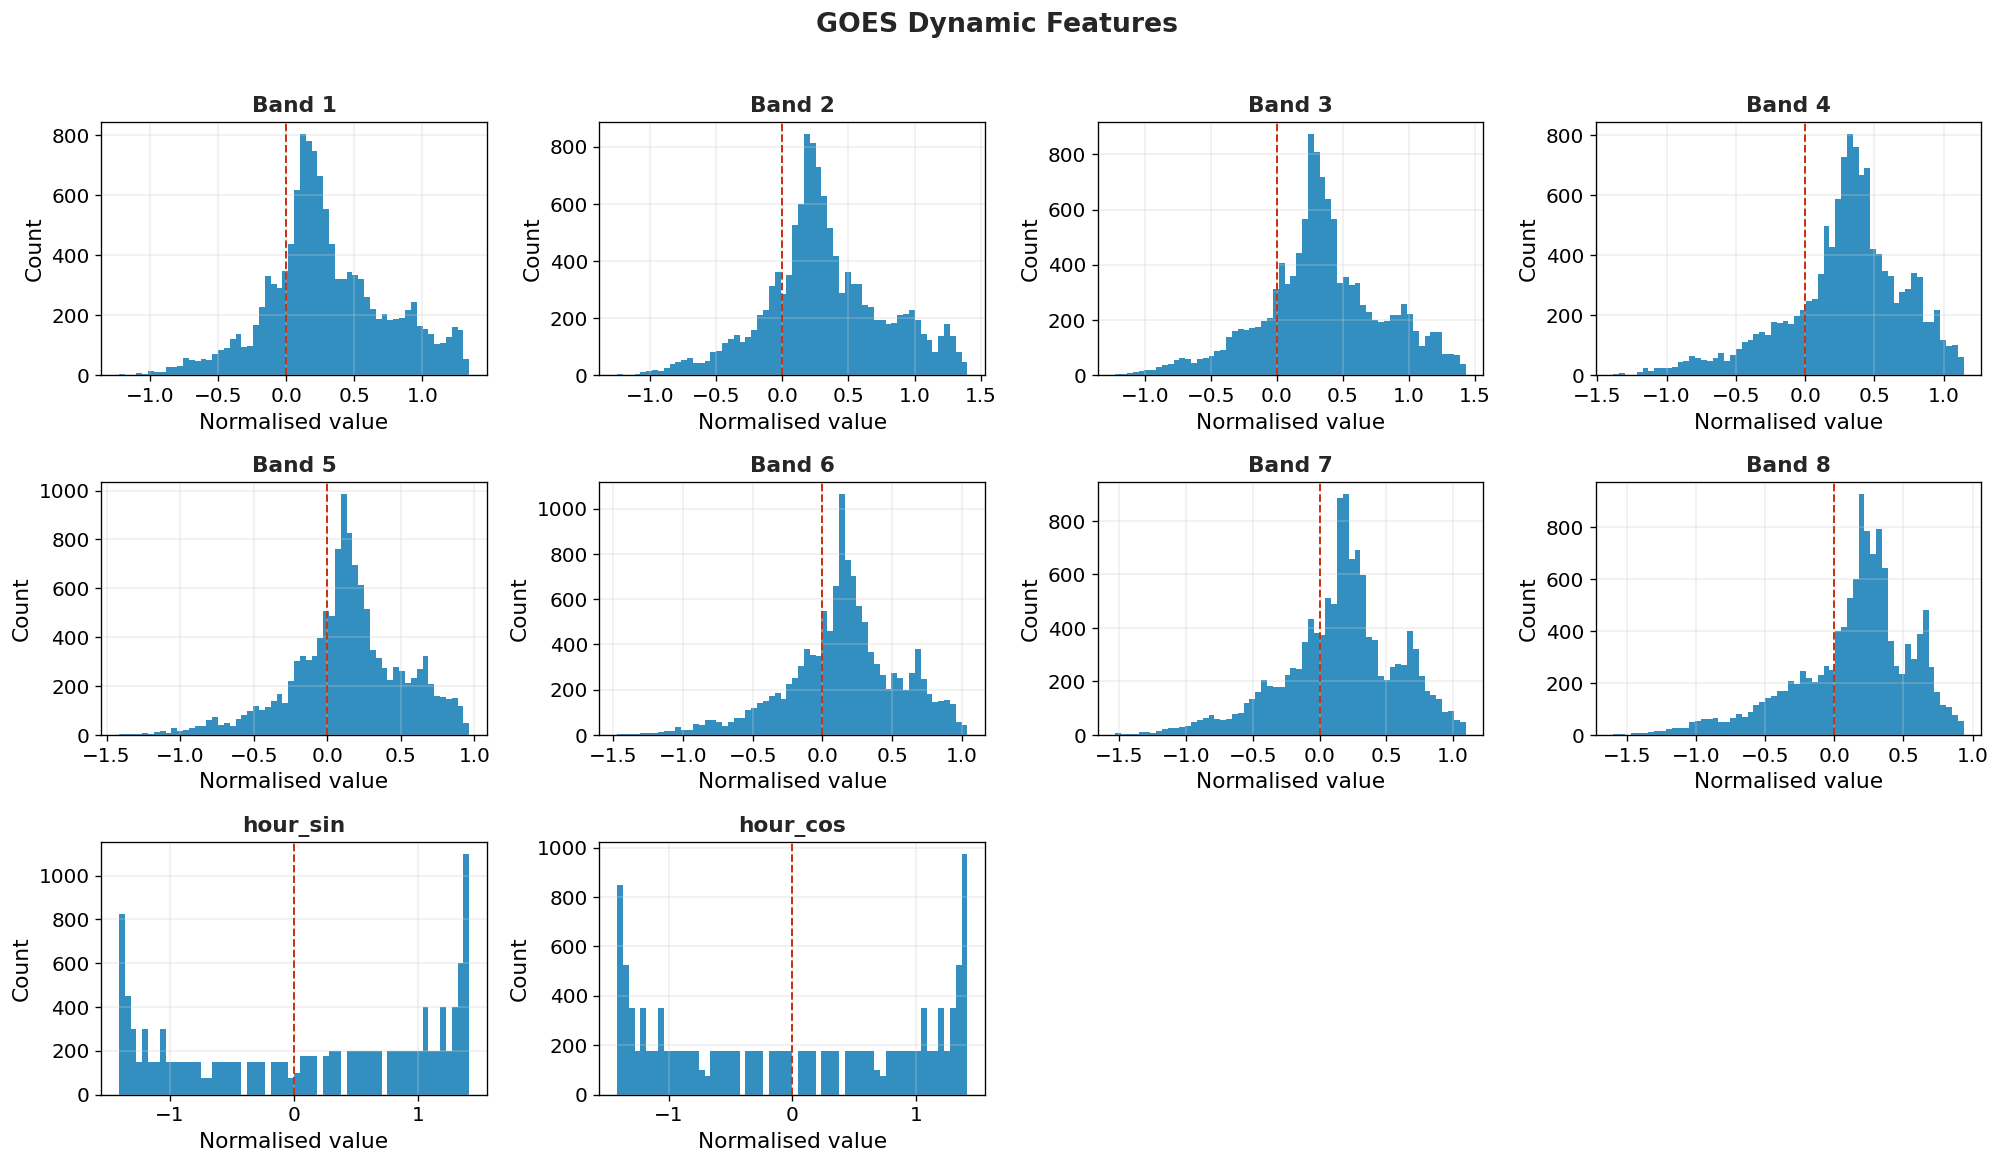

13:20:00 | INFO     | Figure saved -> GNN_Baltimore/figures/features_static_hist.pdf


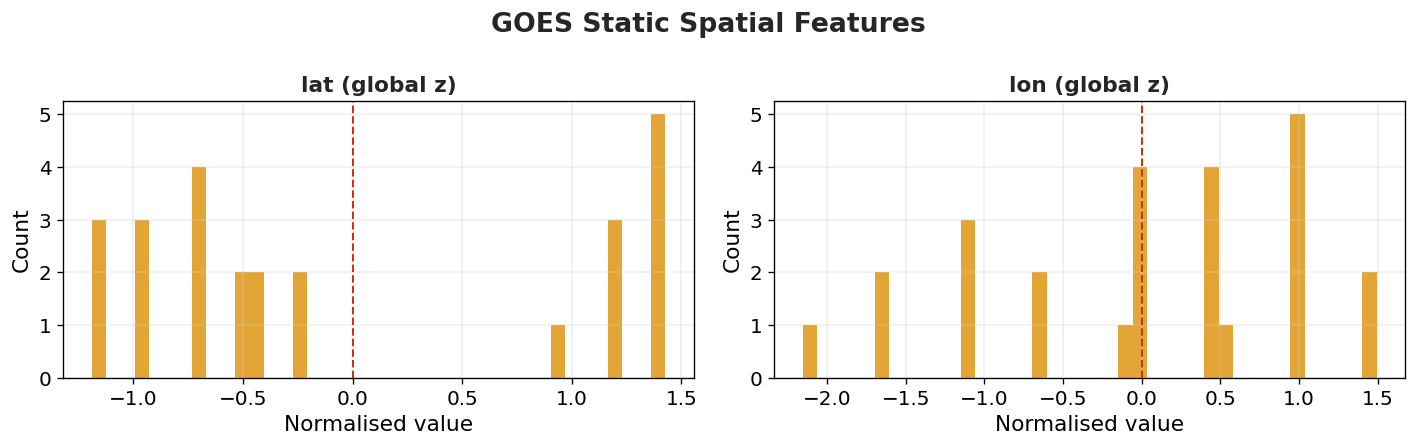

13:20:00 | INFO     | Figure saved -> GNN_Baltimore/figures/features_targets_hist.pdf


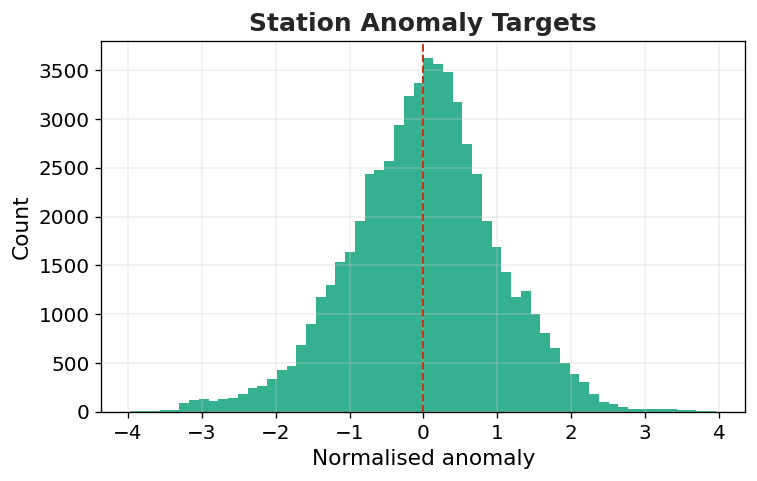

13:20:03 | INFO     | Figure saved -> GNN_Baltimore/figures/split_dist_features.pdf


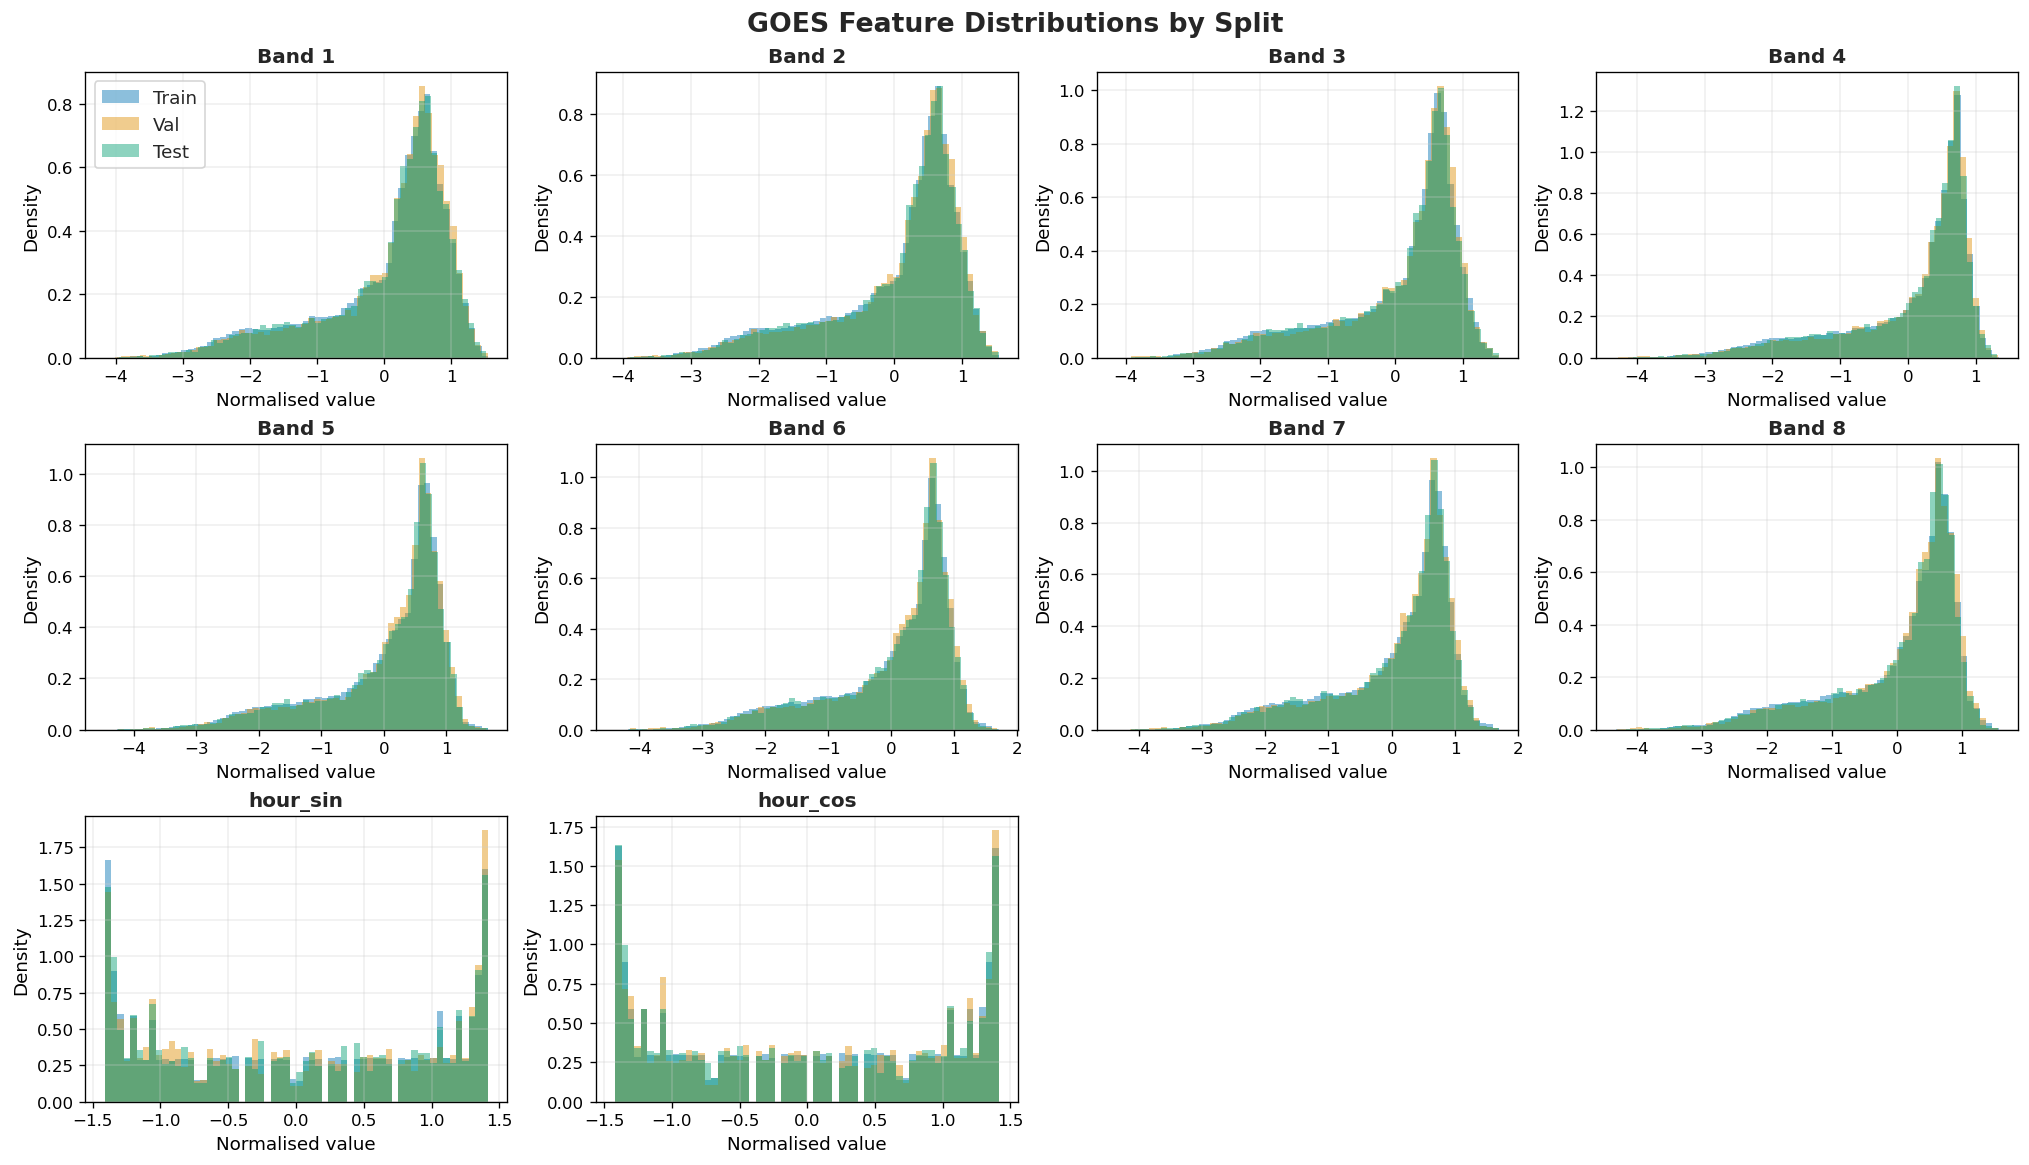

13:20:05 | INFO     | Figure saved -> GNN_Baltimore/figures/split_dist_targets.pdf


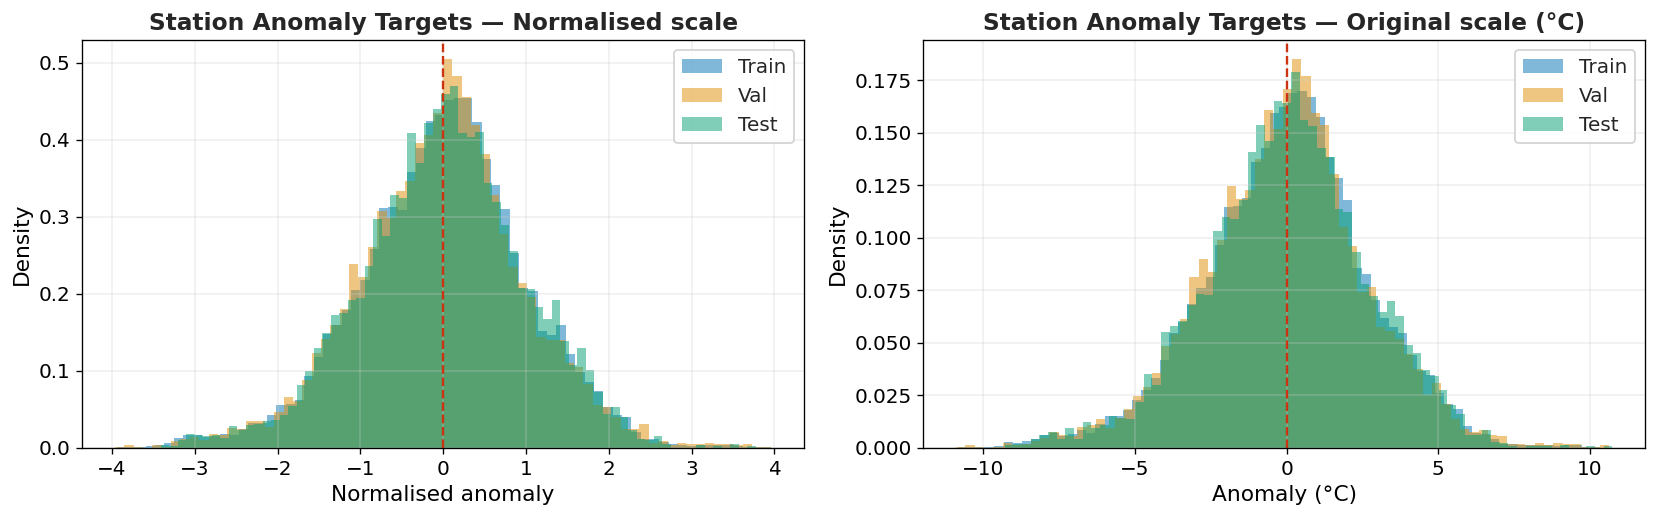

13:20:06 | INFO     | Stage 4 | Topology built — goes->sta edges: 27  |  sta->sta edges (+ self-loops): 9
13:20:06 | INFO     | Figure saved -> GNN_Baltimore/figures/graph_topology.pdf


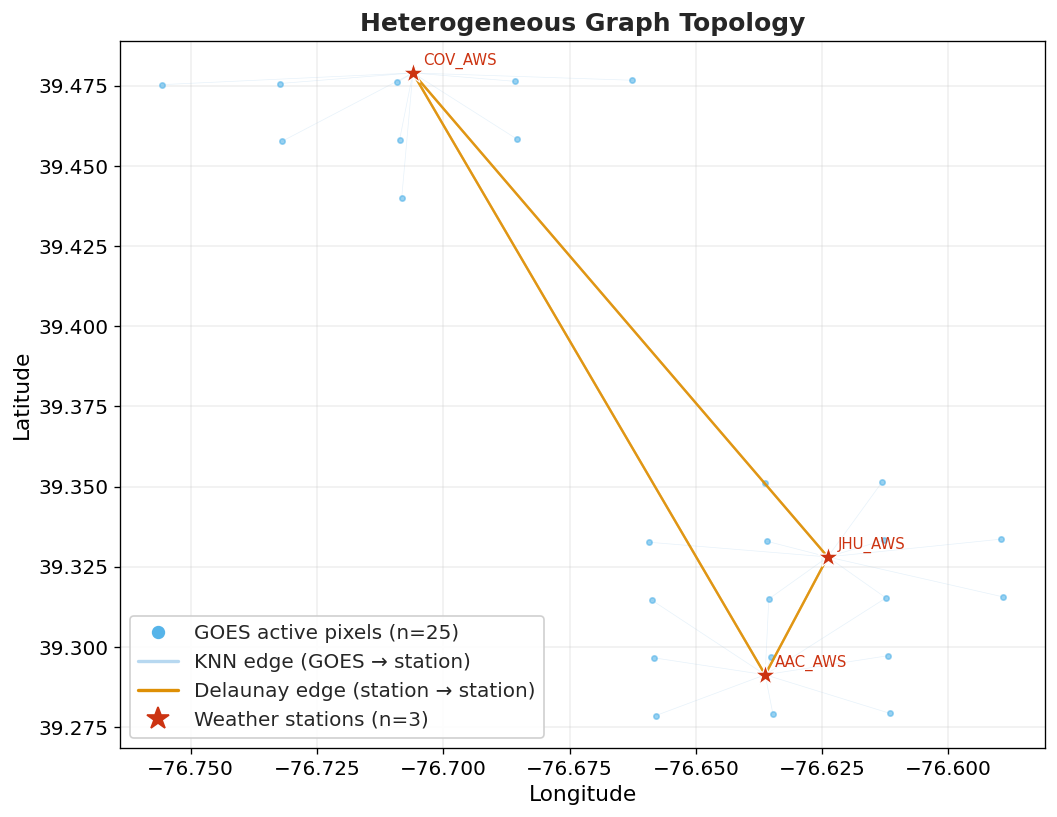

13:20:08 | WARNING  | Stage 4 | Train: skipped 248 / 15902 timesteps due to residual NaN in normalised GOES features.
13:20:08 | INFO     | Stage 4 | Train: 15654 graphs built (248 skipped).


13:20:09 | WARNING  | Stage 4 | Val: skipped 31 / 1985 timesteps due to residual NaN in normalised GOES features.
13:20:09 | INFO     | Stage 4 | Val: 1954 graphs built (31 skipped).


13:20:09 | WARNING  | Stage 4 | Test: skipped 34 / 1985 timesteps due to residual NaN in normalised GOES features.
13:20:09 | INFO     | Stage 4 | Test: 1951 graphs built (34 skipped).
13:20:09 | INFO     | ============================================================
13:20:09 | INFO     | Final graph counts — Train: 15654 | Val: 1954 | Test: 1951
13:20:09 | INFO     | Node feature dims — station.x: 4 | goes.x: 12


In [10]:
# @title Run pipeline (Stage 1 → 4)

# Sanity-check all required paths before doing any work
for attr, path in [
    ('base_dir',         cfg.base_dir),
    ('goes_file',        cfg.goes_file),
    ('latlon_file',      cfg.latlon_file),
    ('station_dir',      cfg.station_dir),
    ('station_loc_file', cfg.station_loc_file),
]:
    assert path.exists(), f'Missing path ({attr}): {path}'

logger.info('All required paths verified.')
logger.info('=' * 60)

# ── Stage 1: Extract raw data ─────────────────────────────────────────────────
raw_data = DataExtractor(cfg).extract()

# Data completeness check (was two separate exploratory cells)
_ds = xr.open_dataset(cfg.goes_file, mask_and_scale=True, engine='netcdf4')
for var in ('goes_original', 'goes_filled'):
    _a = _ds[var].values
    logger.info(f'  NaN in {var}: {np.count_nonzero(np.isnan(_a)) * 100 / _a.size:.3f} %')
del _ds, _a

# ── Stage 2: Split stratified by month ────────────────────────────────────────
splits = DataSplitter(val_ratio=cfg.val_ratio, test_ratio=cfg.test_ratio,
                      seed=cfg.split_seed).split(raw_data['ts_list'])
train_idx, val_idx, test_idx = splits['train_idx'], splits['val_idx'], splits['test_idx']

# ── Stage 3: Feature normalisation (fit on train only) ────────────────────────
feat_prep = FeaturePreprocessor()
norm_data = feat_prep.fit_transform(
    train_idx        = train_idx,
    goes_dynamic_raw = raw_data['goes_dynamic_raw'],
    goes_static_raw  = raw_data['goes_static_raw'],
    sta_raw          = raw_data['sta_raw'],
    stat_pos         = raw_data['stat_pos'],
    active_grid_pos  = raw_data['active_grid_pos'],
)

# ── Diagnostic plots ──────────────────────────────────────────────────────────
Visualizer.plot_preprocessed_features(
    goes_dynamic_norm = norm_data['goes_dynamic_norm'],
    goes_static_norm  = norm_data['goes_static_norm'],
    sta_norm          = norm_data['sta_norm'],
    n_bands           = raw_data['n_bands'],
)
Visualizer.plot_split_distributions(
    goes_dynamic_norm = norm_data['goes_dynamic_norm'],
    sta_norm          = norm_data['sta_norm'],
    sta_raw           = raw_data['sta_raw'],
    train_idx         = train_idx,
    val_idx           = val_idx,
    test_idx          = test_idx,
    n_bands           = raw_data['n_bands'],
)

# ── Stage 4: Graph construction ───────────────────────────────────────────────
graph_prep = GraphPreprocessor(knn_k=cfg.knn_k).build_topology(
    knn_indices     = raw_data['knn_indices'],
    inverse         = raw_data['inverse'],
    n_sta           = raw_data['n_sta'],
    stat_pos        = raw_data['stat_pos'],
    active_grid_pos = raw_data['active_grid_pos'],
)
Visualizer.plot_graph_topology(raw_data, graph_prep)

_graph_kwargs = dict(
    goes_dynamic_norm    = norm_data['goes_dynamic_norm'],
    goes_static_norm     = norm_data['goes_static_norm'],
    sta_norm             = norm_data['sta_norm'],
    sta_raw              = raw_data['sta_raw'],
    stat_pos_norm        = norm_data['stat_pos_norm'],
    active_grid_pos_norm = norm_data['active_grid_pos_norm'],
    time_feats           = raw_data['time_feats'],
    ts_list              = raw_data['ts_list'],
    n_sta                = raw_data['n_sta'],
    n_actif              = raw_data['n_actif'],
)
train_graphs = graph_prep.build_graphs(train_idx, split_name='Train', **_graph_kwargs)
val_graphs   = graph_prep.build_graphs(val_idx,   split_name='Val',   **_graph_kwargs)
test_graphs  = graph_prep.build_graphs(test_idx,  split_name='Test',  **_graph_kwargs)

n_goes_feat = train_graphs[0]['goes'].x.shape[1]
n_sta_feat  = train_graphs[0]['station'].x.shape[1]
n_sta       = raw_data['n_sta']

logger.info('=' * 60)
logger.info(f'Final graph counts — Train: {len(train_graphs)} | '
            f'Val: {len(val_graphs)} | Test: {len(test_graphs)}')
logger.info(f'Node feature dims — station.x: {n_sta_feat} | goes.x: {n_goes_feat}')

## 6 · Model & Trainer

In [11]:
# @title Model — BaltimoreGNN

# ==============================================================================
# MODEL — BaltimoreGNN  (GraphConv message passing + deep residual head)
# ==============================================================================

class BaltimoreGNN(nn.Module):
    """Heterogeneous GNN fusing GOES pixels and weather stations.

    Dimensions:
        station.x  : [n_sta, 4]           lon, lat, hour_sin, hour_cos
        goes.x     : [n_actif, n_bands+4] dynamic + static features
        edge_attr  : [E_knn, 1]           normalised haversine distance
    """

    def __init__(
        self,
        n_goes_feat : int,
        n_sta_feat  : int,
        hidden_dim  : int,
        n_layers    : int = 2,
        dropout     : float = 0.5,
    ) -> None:
        super().__init__()
        self.dropout_p = dropout

        # Initial projection of raw features to hidden_dim
        self.goes_proj = nn.Sequential(
            nn.Linear(n_goes_feat, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
        )
        self.sta_proj = nn.Sequential(
            nn.Linear(n_sta_feat, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
        )

        # Heterogeneous convolution layers
        self.convs     = nn.ModuleList()
        self.norms_sta = nn.ModuleList()

        for _ in range(n_layers):
            conv = HeteroConv(
                {
                    ('goes', 'knn', 'station'): GraphConv(
                        in_channels  = (hidden_dim, hidden_dim),
                        out_channels = hidden_dim,
                    ),
                    ('station', 'delaunay', 'station'): GraphConv(
                        in_channels  = (hidden_dim, hidden_dim),
                        out_channels = hidden_dim,
                    ),
                },
                aggr='mean',
            )
            self.convs.append(conv)
            self.norms_sta.append(nn.LayerNorm(hidden_dim))

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, data: HeteroData) -> torch.Tensor:
        x_goes = self.goes_proj(data['goes'].x)
        x_sta  = self.sta_proj(data['station'].x)

        edge_dict = {
            ('goes', 'knn', 'station'): data['goes', 'knn', 'station'].edge_index,
            ('station', 'delaunay', 'station'): data['station', 'delaunay', 'station'].edge_index,
        }

        goes_knn_weights = data['goes', 'knn', 'station'].edge_attr.squeeze(-1)

        del_index = data['station', 'delaunay', 'station'].edge_index
        delaunay_weights = torch.ones(del_index.size(1), device=del_index.device)

        edge_weight_dict = {
            ('goes', 'knn', 'station'): goes_knn_weights,
            ('station', 'delaunay', 'station'): delaunay_weights,
        }

        for i, conv in enumerate(self.convs):
            out = conv(
                {'goes': x_goes, 'station': x_sta},
                edge_dict,
                edge_weight_dict=edge_weight_dict,
            )
            x_sta = F.relu(self.norms_sta[i](out['station'])) + x_sta
            x_sta = F.dropout(x_sta, p=self.dropout_p, training=self.training)

        return self.head(x_sta).squeeze(-1)


In [12]:
# @title Trainer, Evaluator & DataLoader factory

# ==============================================================================
# DATALOADER FACTORY — pin_memory + workers for fast host→GPU transfer
# ==============================================================================

def make_loader(graphs: List[HeteroData], cfg_: Config, shuffle: bool) -> DataLoader:
    use_cuda = cfg_.device.type == 'cuda'
    return DataLoader(
        graphs,
        batch_size=cfg_.batch_size,
        shuffle=shuffle,
        pin_memory=use_cuda,
        num_workers=cfg_.num_workers,
        persistent_workers=use_cuda and cfg_.num_workers > 0,
    )


# ==============================================================================
# TRAINER & EVALUATOR — optimisation logic unchanged
# ==============================================================================

class Trainer:
    def __init__(self, cfg: Config, model: nn.Module) -> None:
        self.cfg       = cfg
        self.model     = model.to(cfg.device)
        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay
        )
        # Patience aligned with early stopping: LR does not drop too early
        self.scheduler = ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
        )
        self.criterion = (
            nn.MSELoss() if cfg.criterion == 'mse'
            else nn.HuberLoss(delta=cfg.huber_delta)
        )
        # Mixed precision: faster on T4/A100 GPUs, no effect on CPU
        self._use_amp = cfg.device.type == 'cuda'
        self.scaler = (GradScaler('cuda', enabled=self._use_amp) if _AMP_NEW_API
                       else GradScaler(enabled=self._use_amp))
        self.history: Dict[str, List[float]] = {
            'train_loss': [], 'val_loss': [], 'val_mae': []
        }
        self.best_epoch_: int = 0

    def _autocast(self):
        return (autocast('cuda', enabled=self._use_amp) if _AMP_NEW_API
                else autocast(enabled=self._use_amp))

    # ------------------------------------------------------------------
    # Fit
    # ------------------------------------------------------------------

    def fit(
        self,
        train_loader: DataLoader,
        val_loader: DataLoader,
        verbose: bool = True,
    ) -> Dict[str, List[float]]:
        if verbose:
            logger.info(
                f'Model parameters: '
                f'{sum(p.numel() for p in self.model.parameters() if p.requires_grad):,}'
            )
        best_val, best_state, best_epoch, no_improve = float('inf'), None, 0, 0
        loss_name = self.cfg.criterion.upper()

        for epoch in range(1, self.cfg.epochs + 1):
            # ── Training pass ──────────────────────────────────────────────
            self.model.train()
            train_loss = 0.0
            for batch in train_loader:
                batch = batch.to(self.cfg.device, non_blocking=True)
                self.optimizer.zero_grad(set_to_none=True)
                with self._autocast():
                    loss = self.criterion(self.model(batch), batch['station'].y)
                self.scaler.scale(loss).backward()
                self.scaler.unscale_(self.optimizer)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.scaler.step(self.optimizer)
                self.scaler.update()
                train_loss += loss.item()
            train_loss /= len(train_loader)

            # ── Validation pass ────────────────────────────────────────────
            self.model.eval()
            val_loss = val_mae = 0.0
            with torch.no_grad():
                for batch in val_loader:
                    batch    = batch.to(self.cfg.device, non_blocking=True)
                    pred     = self.model(batch)
                    val_loss += self.criterion(pred, batch['station'].y).item()
                    val_mae  += (pred - batch['station'].y).abs().mean().item()
            val_loss /= len(val_loader)
            val_mae  /= len(val_loader)

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_mae'].append(val_mae)   # NOTE: normalised scale
            self.scheduler.step(val_loss)

            if val_loss < best_val:
                best_val, best_state, best_epoch, no_improve = (
                    val_loss, copy.deepcopy(self.model.state_dict()), epoch, 0
                )
            else:
                no_improve += 1

            if verbose and (epoch % 5 == 0 or epoch == 1):
                marker = '  <-- best' if epoch == best_epoch else ''
                logger.info(
                    f'Epoch {epoch:3d}/{self.cfg.epochs} | '
                    f'train {loss_name}={train_loss:.4f} | '
                    f'val {loss_name}={val_loss:.4f} | '
                    f'val MAE={val_mae:.4f} (scaled){marker}'
                )

            if no_improve >= self.cfg.patience:
                if verbose:
                    logger.info(
                        f'Early stopping at epoch {epoch} — '
                        f'no improvement for {self.cfg.patience} epochs.'
                    )
                break

        if verbose:
            logger.info(f'Best val {loss_name}: {best_val:.4f} at epoch {best_epoch}')
        self.best_epoch_ = best_epoch
        self.model.load_state_dict(best_state)
        return self.history

    # ------------------------------------------------------------------
    # Evaluate
    # ------------------------------------------------------------------

    def evaluate(
        self,
        loader      : DataLoader,
        feat_prep   : FeaturePreprocessor,
        split_name  : str,
        n_sta       : int,
        plot        : bool = True,
        verbose     : bool = True,
        fig_name    : str = None,
    ) -> Dict[str, float]:
        self.model.eval()
        all_preds, all_targets = [], []

        with torch.no_grad():
            for batch in loader:
                batch = batch.to(self.cfg.device, non_blocking=True)
                all_preds.append(self.model(batch).cpu().numpy())
                all_targets.append(batch['station'].y.cpu().numpy())

        all_preds   = np.concatenate(all_preds)    # (N * n_sta,)
        all_targets = np.concatenate(all_targets)

        # Inverse-scale: reshape to (N, n_sta), invert, re-flatten
        preds_deg   = feat_prep.inverse_transform_stations(
            all_preds.reshape(-1, n_sta)
        ).ravel()
        targets_deg = feat_prep.inverse_transform_stations(
            all_targets.reshape(-1, n_sta)
        ).ravel()

        rmse  = np.sqrt(mean_squared_error(targets_deg, preds_deg))
        mae   = mean_absolute_error(targets_deg, preds_deg)
        r2    = r2_score(targets_deg, preds_deg)
        r, _  = pearsonr(targets_deg, preds_deg)
        bias  = float(np.mean(preds_deg - targets_deg))
        metrics = {'rmse': rmse, 'mae': mae, 'r2': r2, 'r': r, 'bias': bias}

        if verbose:
            logger.info(f'--- {split_name} Results ---')
            logger.info(
                f'RMSE={rmse:.4f}\u00b0C | MAE={mae:.4f}\u00b0C | '
                f'R\u00b2={r2:.4f} | r={r:.4f} | Bias={bias:.4f}\u00b0C'
            )
        if plot:
            Visualizer.plot_predictions(targets_deg, preds_deg, split_name,
                                        metrics, fig_name=fig_name)
        return metrics


# ── Shared loaders (reused by both HPO stages and the final model) ────────────
train_loader = make_loader(train_graphs, cfg, shuffle=True)
val_loader   = make_loader(val_graphs,   cfg, shuffle=False)
test_loader  = make_loader(test_graphs,  cfg, shuffle=False)
logger.info(f'Loaders ready — batch size {cfg.batch_size}, '
            f'{cfg.num_workers} workers, pin_memory={cfg.device.type == "cuda"}')


13:20:09 | INFO     | Loaders ready — batch size 64, 2 workers, pin_memory=True


## 7 · Hyperparameter tuning — Stage A: architecture

In [13]:
# @title Stage A — grid over hidden_dim × n_layers (MSE loss)

def run_experiment(run_cfg: Config, tag: str) -> Dict[str, Any]:
    """Train one configuration silently and return validation metrics."""
    t0 = time.time()
    torch.manual_seed(0); np.random.seed(0)
    model_i   = BaltimoreGNN(n_goes_feat, n_sta_feat,
                             run_cfg.hidden_dim, run_cfg.n_layers, run_cfg.dropout)
    trainer_i = Trainer(run_cfg, model_i)
    trainer_i.fit(train_loader, val_loader, verbose=False)
    val_m = trainer_i.evaluate(val_loader, feat_prep, tag, n_sta,
                               plot=False, verbose=False)
    dt = time.time() - t0
    logger.info(
        f'  {tag:32s} | val RMSE={val_m["rmse"]:.4f}°C  '
        f'MAE={val_m["mae"]:.4f}  R²={val_m["r2"]:.4f}  '
        f'| best epoch {trainer_i.best_epoch_}  | {dt/60:.1f} min'
    )
    return {'trainer': trainer_i, 'val_metrics': val_m, 'minutes': dt / 60}


logger.info('=' * 70)
logger.info(f'HPO STAGE A — architecture grid '
            f'({len(cfg.hpo_hidden_dims)} x {len(cfg.hpo_n_layers)} configs, MSE loss)')
logger.info('=' * 70)

arch_results = []
for hd, nl in itertools.product(cfg.hpo_hidden_dims, cfg.hpo_n_layers):
    run_cfg = replace(cfg, hidden_dim=hd, n_layers=nl, criterion='mse')
    res = run_experiment(run_cfg, f'A: hidden={hd} layers={nl}')
    arch_results.append({
        'hidden_dim': hd, 'n_layers': nl,
        'val_rmse': res['val_metrics']['rmse'],
        'val_mae' : res['val_metrics']['mae'],
        'val_r2'  : res['val_metrics']['r2'],
        'minutes' : res['minutes'],
    })
    del res
    if cfg.device.type == 'cuda':
        torch.cuda.empty_cache()

df_arch = pd.DataFrame(arch_results)
best_arch = df_arch.loc[df_arch['val_rmse'].idxmin()]
BEST_HIDDEN, BEST_LAYERS = int(best_arch['hidden_dim']), int(best_arch['n_layers'])

logger.info('-' * 70)
logger.info(f'Best architecture: hidden_dim={BEST_HIDDEN}, n_layers={BEST_LAYERS} '
            f'(val RMSE={best_arch["val_rmse"]:.4f}°C)')
print(df_arch.sort_values('val_rmse').to_string(index=False))

13:20:09 | INFO     | ======================================================================
13:20:09 | INFO     | HPO STAGE A — architecture grid (3 x 3 configs, MSE loss)
13:20:09 | INFO     | ======================================================================
13:33:58 | INFO     |   A: hidden=64 layers=2            | val RMSE=1.0617°C  MAE=0.7075  R²=0.8377  | best epoch 200  | 13.8 min
13:49:31 | INFO     |   A: hidden=64 layers=3            | val RMSE=1.0335°C  MAE=0.6738  R²=0.8462  | best epoch 194  | 15.6 min
14:08:39 | INFO     |   A: hidden=64 layers=5            | val RMSE=0.9535°C  MAE=0.6238  R²=0.8691  | best epoch 200  | 19.1 min
14:23:27 | INFO     |   A: hidden=128 layers=2           | val RMSE=0.8431°C  MAE=0.5454  R²=0.8976  | best epoch 191  | 14.8 min
14:34:31 | INFO     |   A: hidden=128 layers=3           | val RMSE=0.7874°C  MAE=0.4913  R²=0.9107  | best epoch 197  | 11.1 min
14:48:15 | INFO     |   A: hidden=128 layers=5           | val RMSE=0.7898°C  MAE=0.

15:31:12 | INFO     | Figure saved -> GNN_Baltimore/figures/hpo_stageA_architecture.pdf


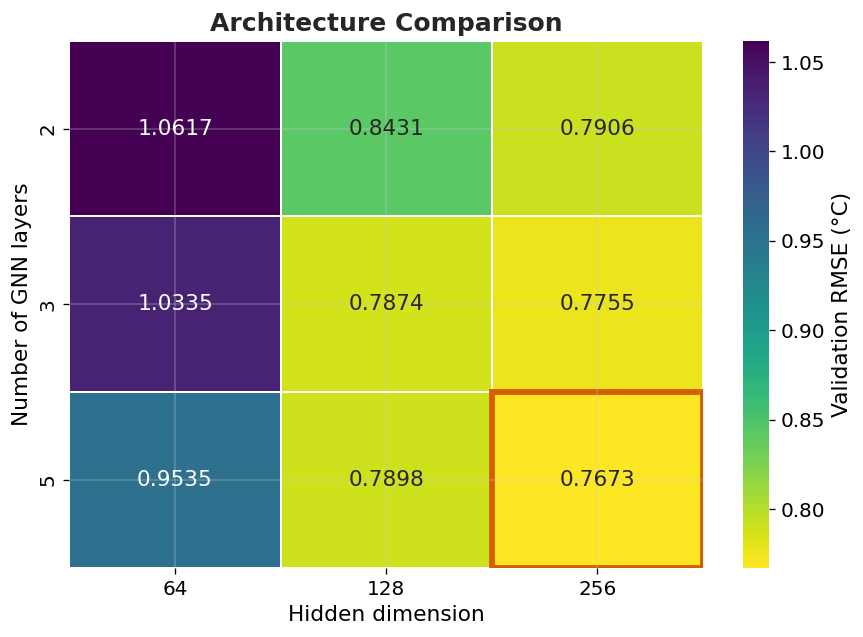

In [14]:
# @title Stage A — results heatmap

pivot = df_arch.pivot(index='n_layers', columns='hidden_dim', values='val_rmse')

fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='viridis_r',
            cbar_kws={'label': 'Validation RMSE (°C)'},
            annot_kws={'fontsize': 13}, linewidths=1, linecolor='white', ax=ax)

# Highlight the best cell
bi = list(pivot.index).index(BEST_LAYERS)
bj = list(pivot.columns).index(BEST_HIDDEN)
ax.add_patch(plt.Rectangle((bj, bi), 1, 1, fill=False,
                           edgecolor=C['accent'], lw=3.5))

ax.set_xlabel('Hidden dimension')
ax.set_ylabel('Number of GNN layers')
ax.set_title('Architecture Comparison')
fig.tight_layout()
save_fig(fig, 'hpo_stageA_architecture')

## 8 · Hyperparameter tuning — Stage B: loss function

In [15]:
# @title Stage B — MSE vs Huber(δ) with the best architecture

loss_configs = [('mse', None)] + [('huber', d) for d in cfg.hpo_huber_deltas]

logger.info('=' * 70)
logger.info(f'HPO STAGE B — loss tuning on hidden={BEST_HIDDEN}, layers={BEST_LAYERS} '
            f'({len(loss_configs)} configs)')
logger.info('=' * 70)

loss_results = []
for crit, delta in loss_configs:
    run_cfg = replace(cfg, hidden_dim=BEST_HIDDEN, n_layers=BEST_LAYERS,
                      criterion=crit, huber_delta=delta if delta is not None else cfg.huber_delta)
    label = 'MSE' if crit == 'mse' else f'Huber δ={delta}'
    res = run_experiment(run_cfg, f'B: {label}')
    loss_results.append({
        'label': label, 'criterion': crit, 'huber_delta': delta,
        'val_rmse': res['val_metrics']['rmse'],
        'val_mae' : res['val_metrics']['mae'],
        'val_r2'  : res['val_metrics']['r2'],
    })
    del res
    if cfg.device.type == 'cuda':
        torch.cuda.empty_cache()

df_loss = pd.DataFrame(loss_results)
best_loss = df_loss.loc[df_loss['val_rmse'].idxmin()]
BEST_CRITERION = best_loss['criterion']
BEST_DELTA     = best_loss['huber_delta'] if BEST_CRITERION == 'huber' else cfg.huber_delta

logger.info('-' * 70)
logger.info(f'Best loss: {best_loss["label"]} (val RMSE={best_loss["val_rmse"]:.4f}°C)')
print(df_loss.sort_values('val_rmse').to_string(index=False))

# ── The final configuration used everywhere downstream ────────────────────────
best_cfg = replace(cfg, hidden_dim=BEST_HIDDEN, n_layers=BEST_LAYERS,
                   criterion=BEST_CRITERION,
                   huber_delta=BEST_DELTA if BEST_DELTA is not None else cfg.huber_delta)
logger.info(f'best_cfg -> hidden={best_cfg.hidden_dim} layers={best_cfg.n_layers} '
            f'loss={best_cfg.criterion}'
            + (f'(δ={best_cfg.huber_delta})' if best_cfg.criterion == 'huber' else ''))

15:31:12 | INFO     | ======================================================================
15:31:12 | INFO     | HPO STAGE B — loss tuning on hidden=256, layers=5 (5 configs)
15:31:12 | INFO     | ======================================================================
15:48:49 | INFO     |   B: MSE                           | val RMSE=0.7082°C  MAE=0.4086  R²=0.9278  | best epoch 199  | 17.6 min
16:08:56 | INFO     |   B: Huber δ=0.25                  | val RMSE=0.6684°C  MAE=0.3871  R²=0.9357  | best epoch 192  | 20.1 min
16:28:44 | INFO     |   B: Huber δ=0.5                   | val RMSE=0.7066°C  MAE=0.4045  R²=0.9281  | best epoch 194  | 19.8 min
16:50:11 | INFO     |   B: Huber δ=1.0                   | val RMSE=0.7724°C  MAE=0.4573  R²=0.9141  | best epoch 191  | 21.4 min
17:13:46 | INFO     |   B: Huber δ=2.0                   | val RMSE=0.7111°C  MAE=0.4208  R²=0.9272  | best epoch 191  | 23.6 min
17:13:47 | INFO     | ----------------------------------------------------------

17:13:47 | INFO     | Figure saved -> GNN_Baltimore/figures/hpo_stageB_loss.pdf


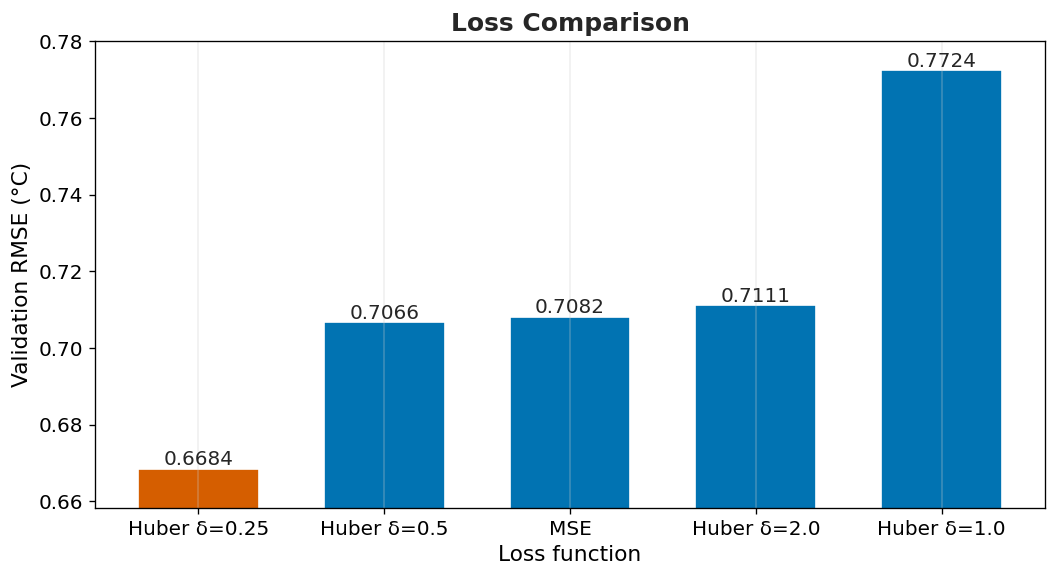

In [16]:
# @title Stage B — results bar chart

df_plot = df_loss.sort_values('val_rmse', ascending=True)
bar_colors = [C['accent'] if lb == best_loss['label'] else C['train']
              for lb in df_plot['label']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(df_plot['label'], df_plot['val_rmse'], color=bar_colors,
              edgecolor='white', width=0.65)
for b, v in zip(bars, df_plot['val_rmse']):
    ax.annotate(f'{v:.4f}', (b.get_x() + b.get_width() / 2, v),
                ha='center', va='bottom', fontsize=12)
ax.set_ylabel('Validation RMSE (°C)')
ax.set_xlabel('Loss function')
ax.set_title('Loss Comparison')
ax.grid(axis='y')
ymin = df_plot['val_rmse'].min()
ax.set_ylim(ymin * 0.985, df_plot['val_rmse'].max() * 1.01)
fig.tight_layout()
save_fig(fig, 'hpo_stageB_loss')

## 9 · Final model — best configuration

17:13:47 | INFO     | Model parameters: 1,420,289
17:13:56 | INFO     | Epoch   1/200 | train HUBER=0.1588 | val HUBER=0.1433 | val MAE=0.6869 (scaled)  <-- best
17:14:27 | INFO     | Epoch   5/200 | train HUBER=0.1273 | val HUBER=0.1200 | val MAE=0.5930 (scaled)  <-- best
17:15:04 | INFO     | Epoch  10/200 | train HUBER=0.1114 | val HUBER=0.1071 | val MAE=0.5395 (scaled)
17:15:43 | INFO     | Epoch  15/200 | train HUBER=0.1014 | val HUBER=0.0964 | val MAE=0.4949 (scaled)  <-- best
17:16:25 | INFO     | Epoch  20/200 | train HUBER=0.0918 | val HUBER=0.0868 | val MAE=0.4544 (scaled)  <-- best
17:17:01 | INFO     | Epoch  25/200 | train HUBER=0.0844 | val HUBER=0.0848 | val MAE=0.4464 (scaled)
17:17:43 | INFO     | Epoch  30/200 | train HUBER=0.0791 | val HUBER=0.0796 | val MAE=0.4236 (scaled)
17:18:26 | INFO     | Epoch  35/200 | train HUBER=0.0720 | val HUBER=0.0744 | val MAE=0.4031 (scaled)
17:19:09 | INFO     | Epoch  40/200 | train HUBER=0.0651 | val HUBER=0.0656 | val MAE=0.3642 (

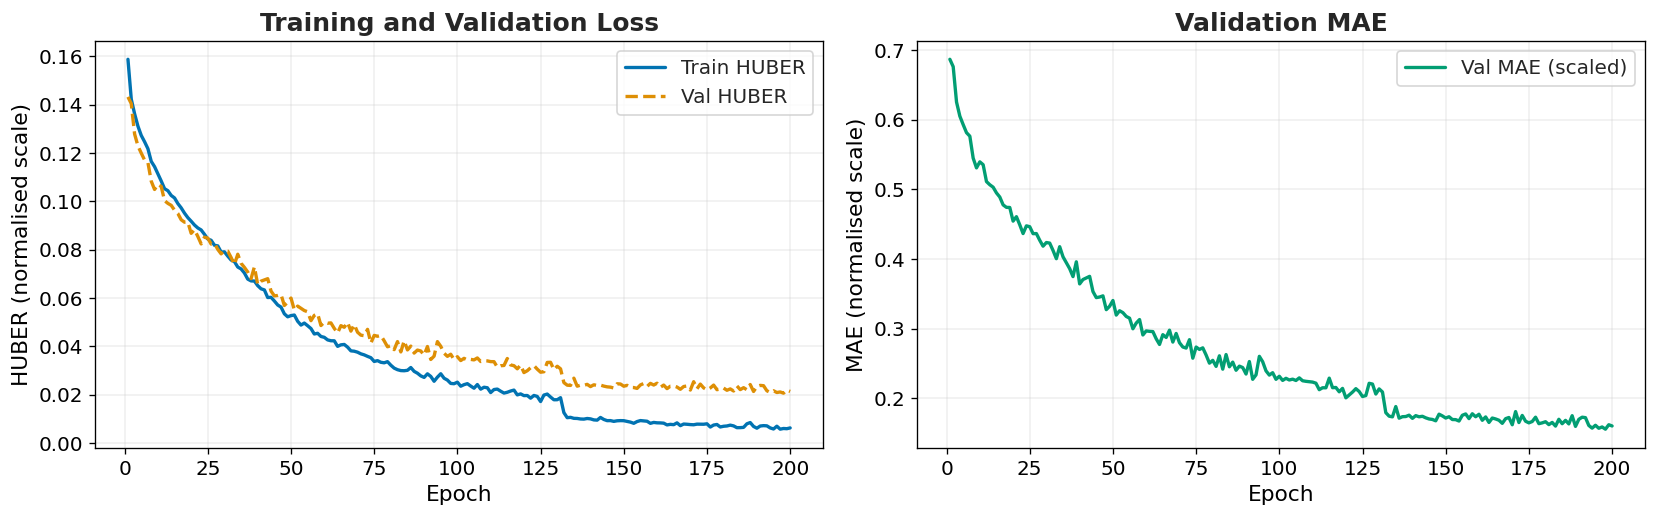

17:39:19 | INFO     | ============================================================
17:39:20 | INFO     | --- Validation Results ---
17:39:20 | INFO     | RMSE=0.7295°C | MAE=0.4195°C | R²=0.9234 | r=0.9610 | Bias=-0.0012°C
17:39:20 | INFO     | Figure saved -> GNN_Baltimore/figures/final_predictions_val.pdf


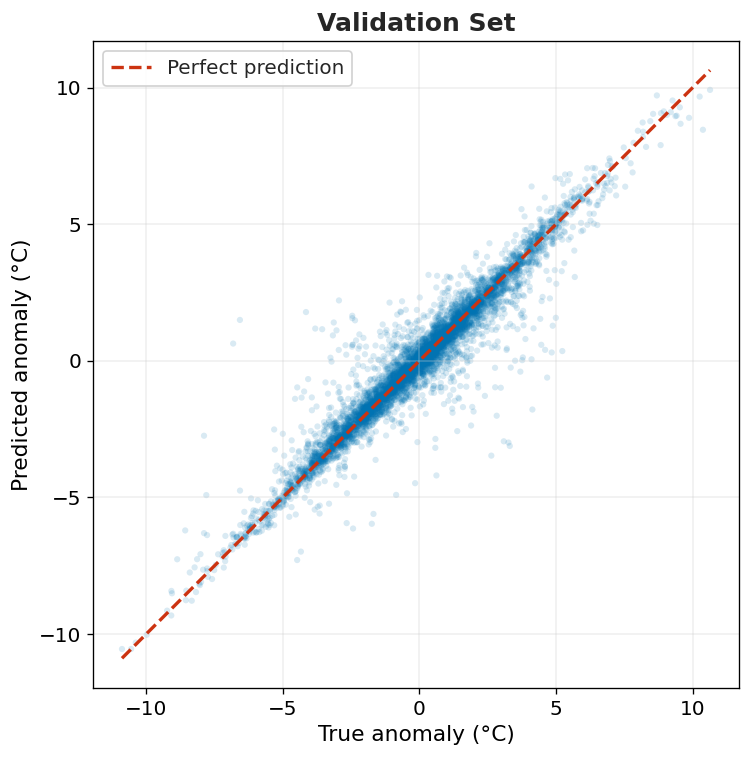

17:39:22 | INFO     | --- Test Results ---
17:39:22 | INFO     | RMSE=0.7187°C | MAE=0.4094°C | R²=0.9254 | r=0.9622 | Bias=-0.0026°C
17:39:22 | INFO     | Figure saved -> GNN_Baltimore/figures/final_predictions_test.pdf


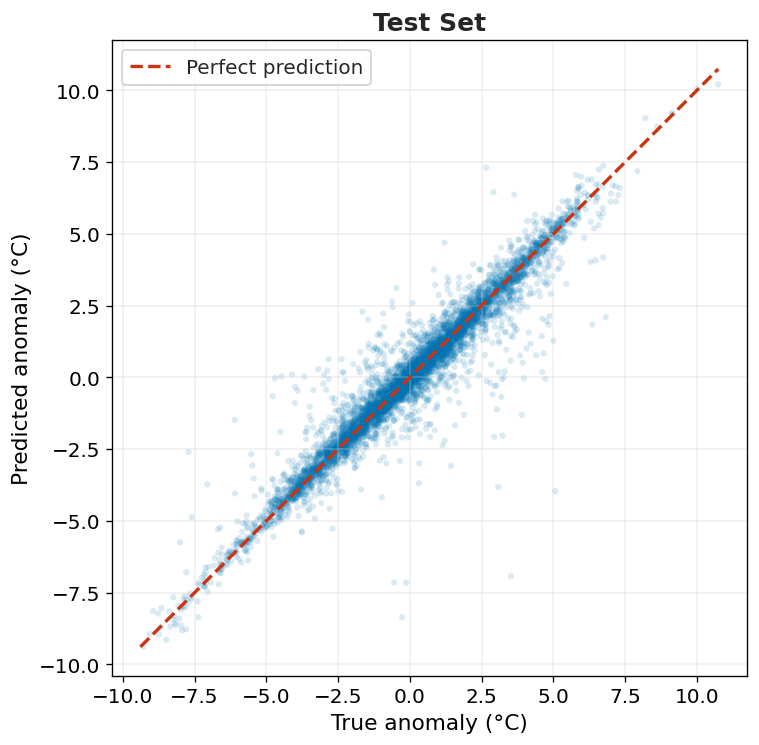

17:39:22 | INFO     | =======================================================
17:39:22 | INFO     | Metric                Validation             Test
17:39:22 | INFO     | =======================================================
17:39:22 | INFO     |   rmse                    0.7295           0.7187
17:39:22 | INFO     |   mae                     0.4195           0.4094
17:39:22 | INFO     |   r2                      0.9234           0.9254
17:39:22 | INFO     |   r                       0.9610           0.9622
17:39:22 | INFO     |   bias                   -0.0012          -0.0026
17:39:22 | INFO     | =======================================================
17:39:22 | INFO     | Final model ready — used for all XAI experiments below.


In [17]:
# @title Train & evaluate the best model

torch.manual_seed(0); np.random.seed(0)
model   = BaltimoreGNN(n_goes_feat, n_sta_feat,
                       best_cfg.hidden_dim, best_cfg.n_layers, best_cfg.dropout)
trainer = Trainer(best_cfg, model)

trainer.fit(train_loader, val_loader, verbose=True)
Visualizer.plot_training_history(trainer.history,
                                 loss_name=best_cfg.criterion.upper(),
                                 fig_name='final_training_history')

logger.info('=' * 60)
val_metrics  = trainer.evaluate(val_loader,  feat_prep, 'Validation', n_sta,
                                fig_name='final_predictions_val')
test_metrics = trainer.evaluate(test_loader, feat_prep, 'Test', n_sta,
                                fig_name='final_predictions_test')

# Summary table
logger.info('=' * 55)
logger.info(f"{'Metric':15s}  {'Validation':>15s}  {'Test':>15s}")
logger.info('=' * 55)
for metric in ['rmse', 'mae', 'r2', 'r', 'bias']:
    logger.info(f'  {metric:13s}  {val_metrics[metric]:>15.4f}  {test_metrics[metric]:>15.4f}')
logger.info('=' * 55)
logger.info('Final model ready — used for all XAI experiments below.')

## 10 · Stability across random splits

In [18]:
# @title Multi-split stability

split_artifacts: Dict[int, Dict[str, Any]] = {}
multi_split_results = []

logger.info('=' * 70)
logger.info(f'MODEL STABILITY — {len(best_cfg.stability_seeds)} different random splits '
            f'(best configuration)')
logger.info('=' * 70)

for split_i, seed in enumerate(best_cfg.stability_seeds):
    logger.info(f'--- Split {split_i + 1}/{len(best_cfg.stability_seeds)} (seed={seed}) ---')

    # New split + normalisation fitted on its training part
    splits_i    = DataSplitter(val_ratio=best_cfg.val_ratio,
                               test_ratio=best_cfg.test_ratio, seed=seed
                               ).split(raw_data['ts_list'])
    feat_prep_i = FeaturePreprocessor()
    norm_data_i = feat_prep_i.fit_transform(
        train_idx        = splits_i['train_idx'],
        goes_dynamic_raw = raw_data['goes_dynamic_raw'],
        goes_static_raw  = raw_data['goes_static_raw'],
        sta_raw          = raw_data['sta_raw'],
        stat_pos         = raw_data['stat_pos'],
        active_grid_pos  = raw_data['active_grid_pos'],
    )
    graph_prep_i = GraphPreprocessor(knn_k=best_cfg.knn_k).build_topology(
        knn_indices     = raw_data['knn_indices'],
        inverse         = raw_data['inverse'],
        n_sta           = raw_data['n_sta'],
        stat_pos        = raw_data['stat_pos'],
        active_grid_pos = raw_data['active_grid_pos'],
    )
    _kw = dict(
        goes_dynamic_norm    = norm_data_i['goes_dynamic_norm'],
        goes_static_norm     = norm_data_i['goes_static_norm'],
        sta_norm             = norm_data_i['sta_norm'],
        sta_raw              = raw_data['sta_raw'],
        stat_pos_norm        = norm_data_i['stat_pos_norm'],
        active_grid_pos_norm = norm_data_i['active_grid_pos_norm'],
        time_feats           = raw_data['time_feats'],
        ts_list              = raw_data['ts_list'],
        n_sta                = raw_data['n_sta'],
        n_actif              = raw_data['n_actif'],
    )
    train_graphs_i = graph_prep_i.build_graphs(splits_i['train_idx'], split_name='Train', **_kw)
    val_graphs_i   = graph_prep_i.build_graphs(splits_i['val_idx'],   split_name='Val',   **_kw)
    test_graphs_i  = graph_prep_i.build_graphs(splits_i['test_idx'],  split_name='Test',  **_kw)

    tl  = make_loader(train_graphs_i, best_cfg, shuffle=True)
    vl  = make_loader(val_graphs_i,   best_cfg, shuffle=False)
    tel = make_loader(test_graphs_i,  best_cfg, shuffle=False)

    torch.manual_seed(seed); np.random.seed(seed)
    model_i   = BaltimoreGNN(n_goes_feat, n_sta_feat,
                             best_cfg.hidden_dim, best_cfg.n_layers, best_cfg.dropout)
    trainer_i = Trainer(best_cfg, model_i)
    trainer_i.fit(tl, vl, verbose=False)

    val_m  = trainer_i.evaluate(vl,  feat_prep_i, f'Val  seed={seed}', n_sta,
                                plot=False, verbose=False)
    test_m = trainer_i.evaluate(tel, feat_prep_i, f'Test seed={seed}', n_sta,
                                plot=False, verbose=False)
    logger.info(f'  seed={seed} | Test RMSE={test_m["rmse"]:.4f}°C  '
                f'MAE={test_m["mae"]:.4f}  R²={test_m["r2"]:.4f}')

    # Test-set predictions (graph by graph) — cached for SHAP
    model_i.eval()
    preds_i = []
    with torch.no_grad():
        for g in test_graphs_i:
            g_dev = g.to(best_cfg.device)
            pred  = model_i(g_dev)
            pred  = pred.squeeze(-1) if pred.dim() > 1 else pred
            preds_i.append(pred.cpu())
    preds_i = torch.stack(preds_i, dim=0)   # (T_test, n_sta)

    split_artifacts[seed] = {
        'test_graphs': test_graphs_i,
        'graph_prep' : graph_prep_i,
        'preds'      : preds_i,
    }
    multi_split_results.append({
        'seed'    : seed,
        'val_r2'  : val_m['r2'],  'val_rmse' : val_m['rmse'],  'val_mae' : val_m['mae'],
        'test_r2' : test_m['r2'], 'test_rmse': test_m['rmse'], 'test_mae': test_m['mae'],
    })

    # Free everything SHAP does not need
    del model_i, trainer_i, train_graphs_i, val_graphs_i, tl, vl, tel
    if best_cfg.device.type == 'cuda':
        torch.cuda.empty_cache()

df_splits = pd.DataFrame(multi_split_results)

print('\n' + '=' * 80)
print(f'MODEL STABILITY — {len(best_cfg.stability_seeds)} DIFFERENT RANDOM SPLITS')
print('A low standard deviation means results do not depend on the random split.')
print('=' * 80)
print(df_splits.to_string(index=False))
print('\n--- Standard deviation (stability measure) ---')
for col in ['test_r2', 'test_rmse', 'test_mae']:
    print(f'  {col:12s} : mean={df_splits[col].mean():.4f}  std={df_splits[col].std():.4f}')

17:39:22 | INFO     | ======================================================================
17:39:22 | INFO     | MODEL STABILITY — 5 different random splits (best configuration)
17:39:22 | INFO     | ======================================================================
17:39:22 | INFO     | --- Split 1/5 (seed=42) ---
17:39:22 | INFO     | Stage 2 | Random split stratified by month — Train: 15902 (80.0%)  |  Val: 1985 (10.0%)  |  Test: 1985 (10.0%)
17:39:22 | INFO     | Stage 3 | Fitting on 15902 training timesteps ...
17:39:23 | INFO     | Stage 3 | FeaturePreprocessor fitted successfully.
17:39:23 | INFO     | Stage 4 | Topology built — goes->sta edges: 27  |  sta->sta edges (+ self-loops): 9


17:39:28 | WARNING  | Stage 4 | Train: skipped 248 / 15902 timesteps due to residual NaN in normalised GOES features.
17:39:28 | INFO     | Stage 4 | Train: 15654 graphs built (248 skipped).


17:39:28 | WARNING  | Stage 4 | Val: skipped 31 / 1985 timesteps due to residual NaN in normalised GOES features.
17:39:28 | INFO     | Stage 4 | Val: 1954 graphs built (31 skipped).


17:39:29 | WARNING  | Stage 4 | Test: skipped 34 / 1985 timesteps due to residual NaN in normalised GOES features.
17:39:29 | INFO     | Stage 4 | Test: 1951 graphs built (34 skipped).


18:04:34 | INFO     |   seed=42 | Test RMSE=0.8025°C  MAE=0.4482  R²=0.9070
18:04:42 | INFO     | --- Split 2/5 (seed=7) ---
18:04:42 | INFO     | Stage 2 | Random split stratified by month — Train: 15902 (80.0%)  |  Val: 1985 (10.0%)  |  Test: 1985 (10.0%)
18:04:42 | INFO     | Stage 3 | Fitting on 15902 training timesteps ...
18:04:42 | INFO     | Stage 3 | FeaturePreprocessor fitted successfully.
18:04:42 | INFO     | Stage 4 | Topology built — goes->sta edges: 27  |  sta->sta edges (+ self-loops): 9


...

18:49:38 | INFO     |   seed=999 | Test RMSE=0.7802°C  MAE=0.4300  R²=0.9101
18:49:44 | INFO     | --- Split 5/5 (seed=2024) ---
18:49:44 | INFO     | Stage 2 | Random split stratified by month — Train: 15902 (80.0%)  |  Val: 1985 (10.0%)  |  Test: 1985 (10.0%)
18:49:44 | INFO     | Stage 3 | Fitting on 15902 training timesteps ...
18:49:44 | INFO     | Stage 3 | FeaturePreprocessor fitted successfully.
18:49:44 | INFO     | Stage 4 | Topology built — goes->sta edges: 27  |  sta->sta edges (+ self-loops): 9


18:49:45 | WARNING  | Stage 4 | Train: skipped 256 / 15902 timesteps due to residual NaN in normalised GOES features.
18:49:45 | INFO     | Stage 4 | Train: 15646 graphs built (256 skipped).


18:49:45 | WARNING  | Stage 4 | Val: skipped 33 / 1985 timesteps due to residual NaN in normalised GOES features.
18:49:45 | INFO     | Stage 4 | Val: 1952 graphs built (33 skipped).


18:49:46 | WARNING  | Stage 4 | Test: skipped 24 / 1985 timesteps due to residual NaN in normalised GOES features.
18:49:46 | INFO     | Stage 4 | Test: 1961 graphs built (24 skipped).


19:03:45 | INFO     |   seed=2024 | Test RMSE=0.7457°C  MAE=0.4276  R²=0.9195

MODEL STABILITY — 5 DIFFERENT RANDOM SPLITS
A low standard deviation means results do not depend on the random split.
 seed   val_r2  val_rmse  val_mae  test_r2  test_rmse  test_mae
   42 0.917124  0.758614 0.433227 0.907042   0.802499  0.448210
    7 0.914502  0.776944 0.437513 0.904821   0.787069  0.429457
  123 0.912365  0.787445 0.451982 0.903639   0.829920  0.454929
  999 0.919587  0.775582 0.432633 0.910055   0.780154  0.430040
 2024 0.922413  0.744500 0.418587 0.919545   0.745690  0.427634

--- Standard deviation (stability measure) ---
  test_r2      : mean=0.9090  std=0.0064
  test_rmse    : mean=0.7891  std=0.0309
  test_mae     : mean=0.4381  std=0.0126


19:03:51 | INFO     | Figure saved -> GNN_Baltimore/figures/stability_splits.pdf


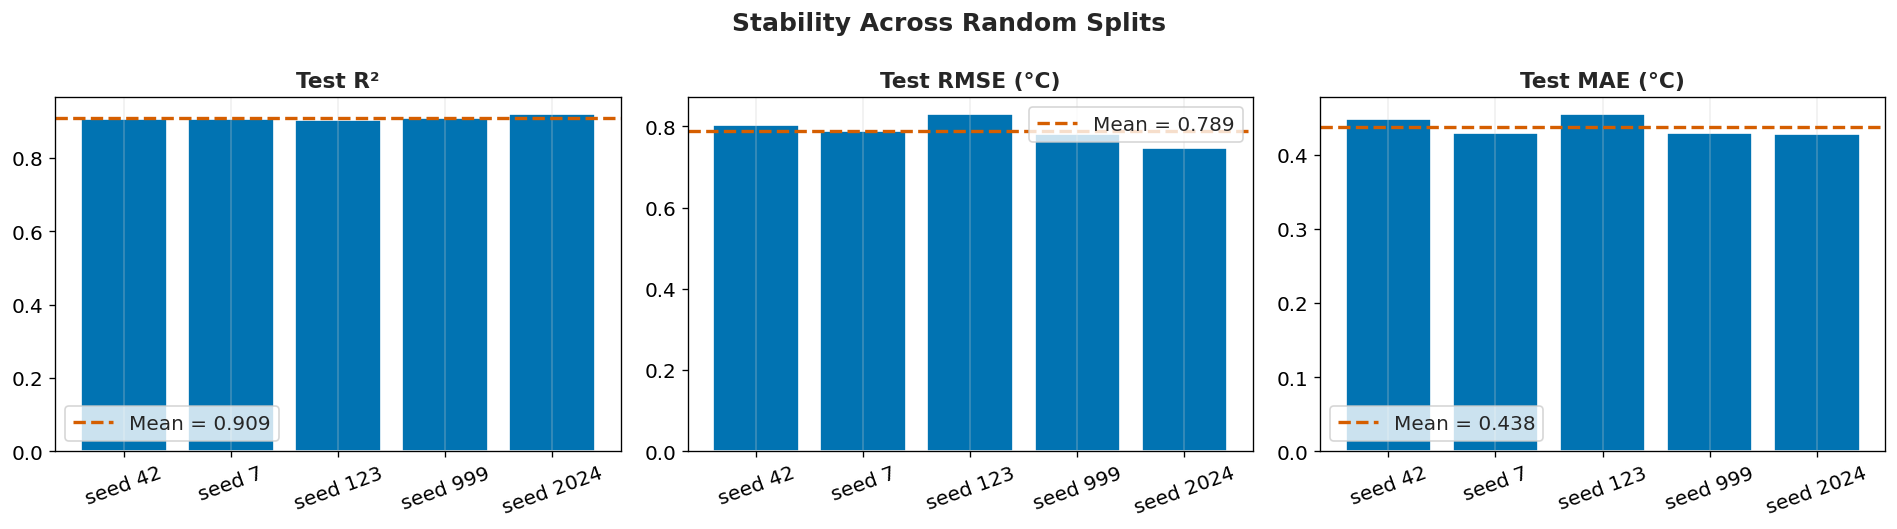

In [19]:
# @title Stability — bar charts

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric, label in zip(
    axes,
    ['test_r2', 'test_rmse', 'test_mae'],
    ['Test R²', 'Test RMSE (°C)', 'Test MAE (°C)'],
):
    ax.bar([f'seed {s}' for s in df_splits['seed']], df_splits[metric],
           color=C['train'], edgecolor='white')
    ax.axhline(df_splits[metric].mean(), color=C['accent'], ls='--', lw=2,
               label=f'Mean = {df_splits[metric].mean():.3f}')
    ax.set_title(label, fontsize=13)
    ax.tick_params(axis='x', rotation=20)
    ax.legend()
    ax.grid(axis='y')

fig.suptitle('Stability Across Random Splits', fontsize=15, fontweight='bold')
fig.tight_layout()
save_fig(fig, 'stability_splits')

## 11 · XAI — explaining the best model

Four methods:

| Method | Question answered |
|--------|-------------------|
| 1 · Correlation heatmaps | How do the inputs a station "sees" co-vary? |
| 2 · Permutation — shuffle one | How much does the model degrade when one variable is destroyed? |
| 3 · Permutation — leave one out | How much signal does one variable carry *alone*? |
| 4 · SHAP surrogate | Per-station attribution, averaged over the 5 stability models |

In [20]:
# @title XAI setup — feature groups, cached GPU batches, baseline

# goes.x column layout (n_actif, 12):
#   0-3 : goes_filled_C13..C16      4-7 : anom_C13..C16
#   8-9 : hour_sin, hour_cos        10  : latitude   11 : longitude
FEATURE_GROUPS = {
    'goes_filled_C13': [0],  'goes_filled_C14': [1],
    'goes_filled_C15': [2],  'goes_filled_C16': [3],
    'anom_C13': [4], 'anom_C14': [5], 'anom_C15': [6], 'anom_C16': [7],
    'hour_sin': [8], 'hour_cos': [9],
    'latitude': [10], 'longitude': [11],
}
ALL_GROUPS = list(FEATURE_GROUPS.keys()) + ['distance']   # 'distance' = KNN edge attr

station_names = raw_data['stat_pos'].index.tolist()
criterion_eval = trainer.criterion
loss_label = best_cfg.criterion.upper() + (
    f' (δ={best_cfg.huber_delta})' if best_cfg.criterion == 'huber' else '')

# ── Collate the test set into GPU-resident batches ONCE ───────────────────────
# All XAI evaluations reuse these; permutations mutate columns in place.
test_batches = [b.to(best_cfg.device)
                for b in DataLoader(test_graphs, batch_size=best_cfg.batch_size,
                                    shuffle=False)]
logger.info(f'Cached {len(test_batches)} test batches on {best_cfg.device}.')


def eval_on_batches(model_, batches) -> Dict[str, float]:
    """Loss / RMSE / MAE / R² on pre-collated batches (°C scale via y_raw)."""
    model_.eval()
    total_loss = 0.0
    all_preds_raw, all_targets_raw = [], []
    with torch.no_grad():
        for batch in batches:
            pred = model_(batch)
            total_loss += criterion_eval(pred, batch['station'].y).item()
            p_np = pred.cpu().numpy().reshape(-1, n_sta)
            y_np = batch['station'].y_raw.cpu().numpy().reshape(-1, n_sta)
            all_preds_raw.append(p_np * feat_prep.sta_scaler_.scale_
                                 + feat_prep.sta_scaler_.mean_)
            all_targets_raw.append(y_np)
    preds_flat   = np.concatenate(all_preds_raw,   axis=0).ravel()
    targets_flat = np.concatenate(all_targets_raw, axis=0).ravel()
    return {
        'loss': total_loss / len(batches),
        'rmse': np.sqrt(mean_squared_error(targets_flat, preds_flat)),
        'mae' : mean_absolute_error(targets_flat, preds_flat),
        'r2'  : r2_score(targets_flat, preds_flat),
    }


# ── In-place permutation engine ───────────────────────────────────────────────

def _get_group_tensors(batches, group):
    """Return the list of per-batch tensors holding this group's values."""
    if group == 'distance':
        return [b['goes', 'knn', 'station'].edge_attr for b in batches]
    idx = FEATURE_GROUPS[group]
    return [b['goes'].x[:, idx] for b in batches]


def shuffle_groups_(batches, groups, seed) -> Dict[str, list]:
    """Shuffle each group's values globally across the whole test set, in place.

    Returns a backup {group: [per-batch original tensors]} for restore_().
    """
    gen = torch.Generator().manual_seed(int(seed) if seed is not None else 0)
    backup: Dict[str, list] = {}
    for g_i, group in enumerate(groups):
        tensors = _get_group_tensors(batches, group)
        backup[group] = [t.clone() for t in tensors]
        flat = torch.cat([t.reshape(t.shape[0], -1).cpu() for t in tensors], dim=0)
        perm = torch.randperm(flat.shape[0], generator=gen)
        flat = flat[perm]
        offset = 0
        for b, t in zip(batches, tensors):
            n = t.shape[0]
            chunk = flat[offset:offset + n].to(t.device).reshape(t.shape)
            if group == 'distance':
                b['goes', 'knn', 'station'].edge_attr = chunk
            else:
                b['goes'].x[:, FEATURE_GROUPS[group]] = chunk
            offset += n
    return backup


def restore_(batches, backup) -> None:
    for group, tensors in backup.items():
        for b, t in zip(batches, tensors):
            if group == 'distance':
                b['goes', 'knn', 'station'].edge_attr = t
            else:
                b['goes'].x[:, FEATURE_GROUPS[group]] = t


# ── Shared bar-plot helper: same variable = same colour, everywhere ───────────

def xai_barh(ax, variables, values, errors=None, xlabel='', title=''):
    #colors = [FEATURE_COLORS[v] for v in variables]
    colors = ["#C41E3A" for v in variables]
    ax.barh(variables, values, xerr=errors, color=colors,
            capsize=3, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', lw=1)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(xlabel)
    ax.grid(axis='x')


# ── Baseline: best model on the untouched test set ────────────────────────────
baseline = eval_on_batches(model, test_batches)
logger.info(f'Baseline (no shuffling) : Loss={baseline["loss"]:.4f} | '
            f'RMSE={baseline["rmse"]:.4f} | MAE={baseline["mae"]:.4f} | '
            f'R²={baseline["r2"]:.4f}')

19:03:52 | INFO     | Cached 31 test batches on cuda.
19:03:52 | INFO     | Baseline (no shuffling) : Loss=0.0198 | RMSE=0.7188 | MAE=0.4094 | R²=0.9254


### 11.1 · Correlation heatmaps per station

Average of the 9 neighbouring GOES pixels per timestep = "what the station sees".
Vectorised over all timesteps at once.

19:03:52 | INFO     | Computing correlation heatmaps for each station...
19:03:52 | INFO     | Figure saved -> GNN_Baltimore/figures/xai1_corr_BSEC-AAC_AWS.pdf


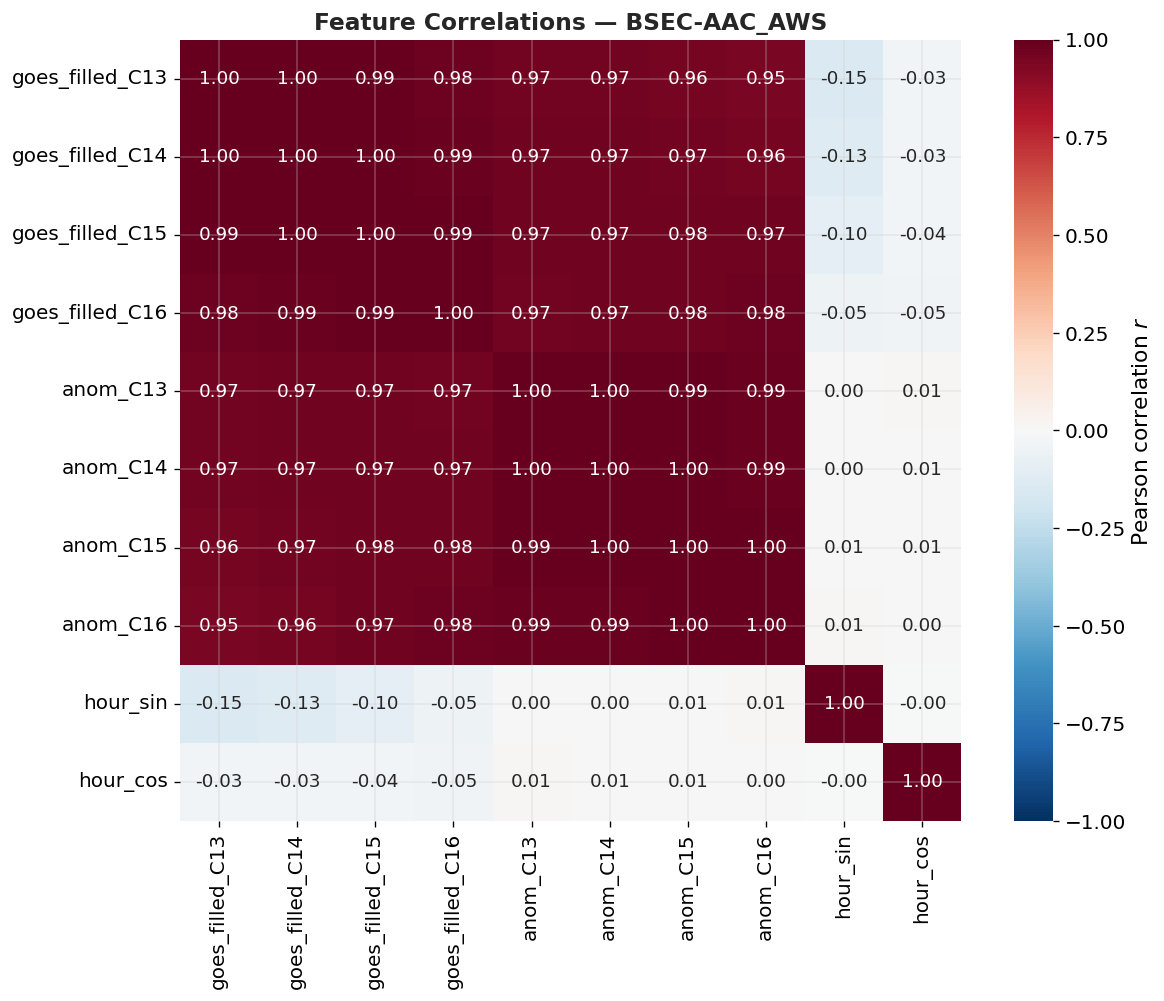

19:03:53 | INFO     | Figure saved -> GNN_Baltimore/figures/xai1_corr_BSEC-COV_AWS.pdf


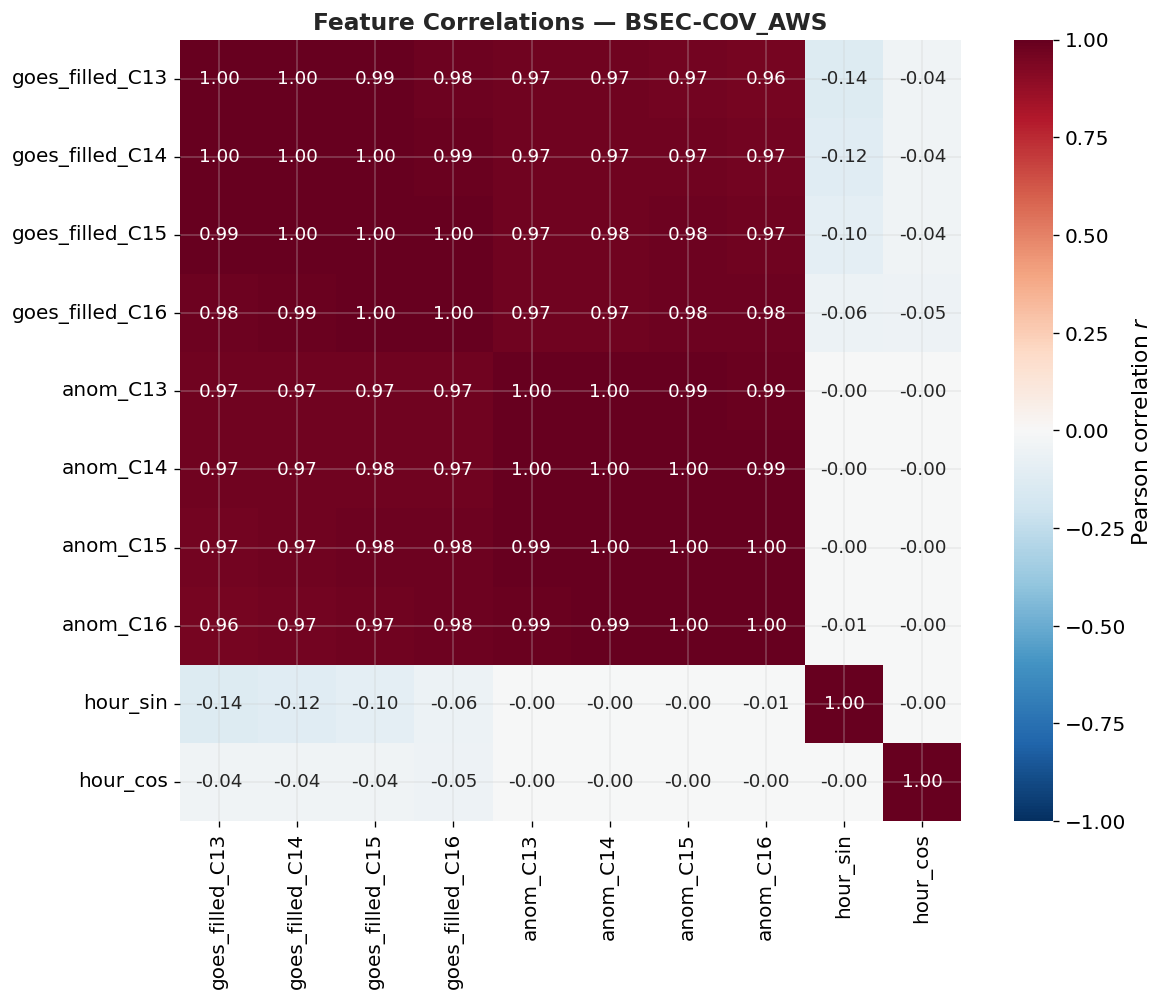

19:03:53 | INFO     | Figure saved -> GNN_Baltimore/figures/xai1_corr_BSEC-JHU_AWS.pdf


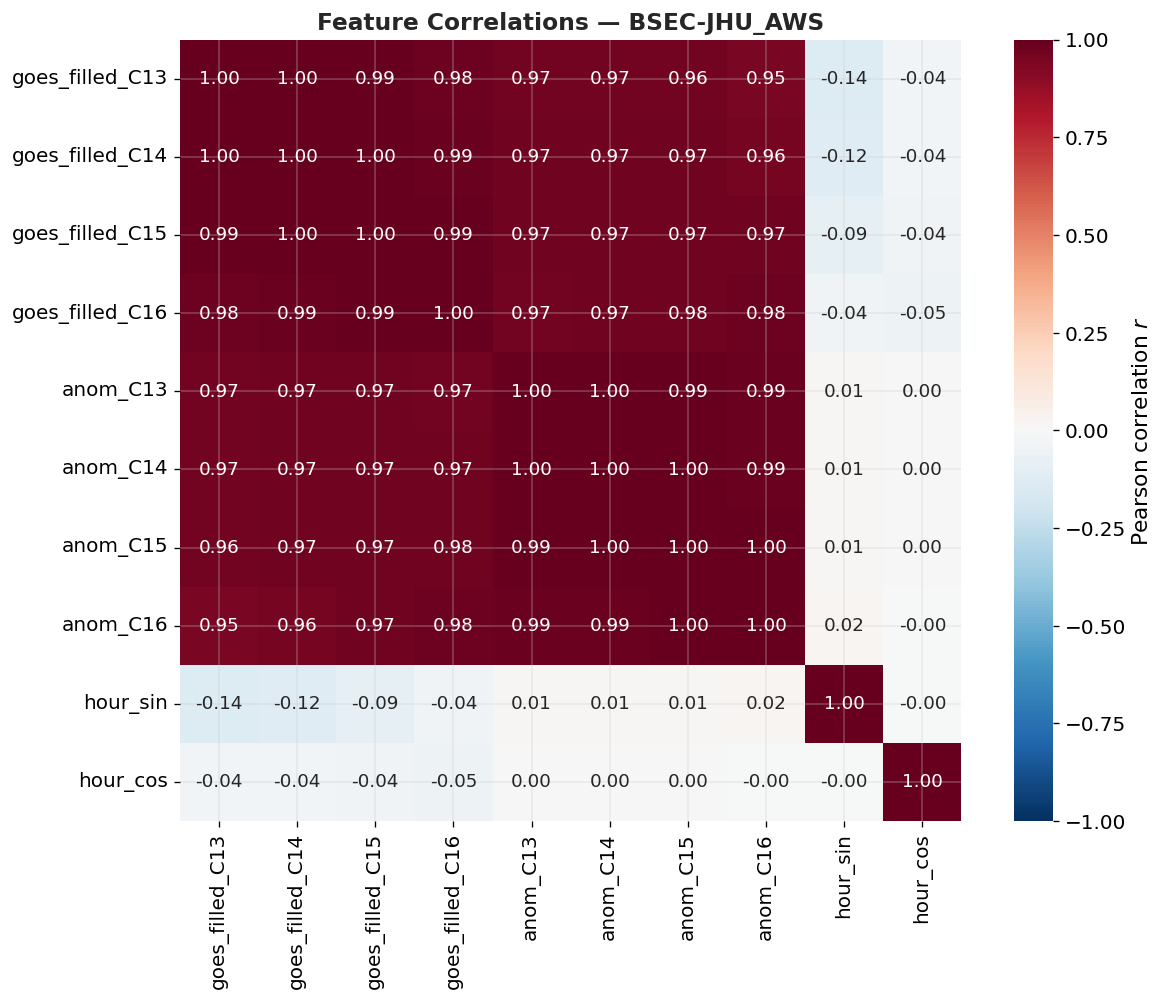

19:03:53 | INFO     | Correlation heatmaps completed for all stations.


In [21]:
# @title XAI 1 — correlation heatmap per station

corr_col_names = [
    'goes_filled_C13', 'goes_filled_C14', 'goes_filled_C15', 'goes_filled_C16',
    'anom_C13', 'anom_C14', 'anom_C15', 'anom_C16',
    'hour_sin', 'hour_cos',
]

# Stack all test-set GOES features once: (T_test, n_actif, 12)
goes_x_stack = torch.stack([g['goes'].x for g in test_graphs]).numpy()
edge_index_np = graph_prep.edge_index_goes_sta_.numpy()

logger.info('Computing correlation heatmaps for each station...')

for s_idx, s_name in enumerate(station_names):
    neighbor_idx = edge_index_np[0][edge_index_np[1] == s_idx]     # (k,)
    # Mean over the k neighbouring pixels, first 10 (dynamic) features only
    feat_matrix = np.nanmean(goes_x_stack[:, neighbor_idx, :10], axis=1)   # (T, 10)
    corr_matrix = pd.DataFrame(feat_matrix, columns=corr_col_names).corr()

    fig, ax = plt.subplots(figsize=(10.5, 8.5))
    sns.heatmap(
        corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
        vmin=-1, vmax=1, square=True, ax=ax,
        annot_kws={'fontsize': 11},
        cbar_kws={'label': 'Pearson correlation $r$'},
    )
    ax.set_title(f'Feature Correlations — {s_name}', fontsize=14)
    fig.tight_layout()
    save_fig(fig, f'xai1_corr_{s_name}')

logger.info('Correlation heatmaps completed for all stations.')

### 11.2 · Permutation importance — shuffle one at a time

Destroy one variable (global shuffle across all timesteps and pixels), measure the
degradation of 4 metrics, repeat `n_repeats_pfi` times. Positive delta = the model
relied on that variable.

19:03:56 | INFO     |   goes_filled_C13    | Loss+0.1318 RMSE+1.7967 MAE+1.5322 R² drop +0.8388
19:03:57 | INFO     |   goes_filled_C14    | Loss+0.1555 RMSE+2.1372 MAE+1.7881 R² drop +1.1028
19:03:59 | INFO     |   goes_filled_C15    | Loss+0.1822 RMSE+2.4551 MAE+2.0809 R² drop +1.3795
19:04:01 | INFO     |   goes_filled_C16    | Loss+0.1769 RMSE+2.4338 MAE+2.0240 R² drop +1.3601
19:04:03 | INFO     |   anom_C13           | Loss+0.1811 RMSE+2.4273 MAE+2.0455 R² drop +1.3541
19:04:05 | INFO     |   anom_C14           | Loss+0.1284 RMSE+1.8128 MAE+1.4901 R² drop +0.8505
19:04:07 | INFO     |   anom_C15           | Loss+0.2321 RMSE+3.0627 MAE+2.6218 R² drop +1.9895
19:04:08 | INFO     |   anom_C16           | Loss+0.1648 RMSE+2.2288 MAE+1.9001 R² drop +1.1795
19:04:10 | INFO     |   hour_sin           | Loss+0.1273 RMSE+1.9972 MAE+1.4700 R² drop +0.9902
19:04:12 | INFO     |   hour_cos           | Loss+0.0727 RMSE+1.0903 MAE+0.8712 R² drop +0.3979
19:04:14 | INFO     |   latitude        

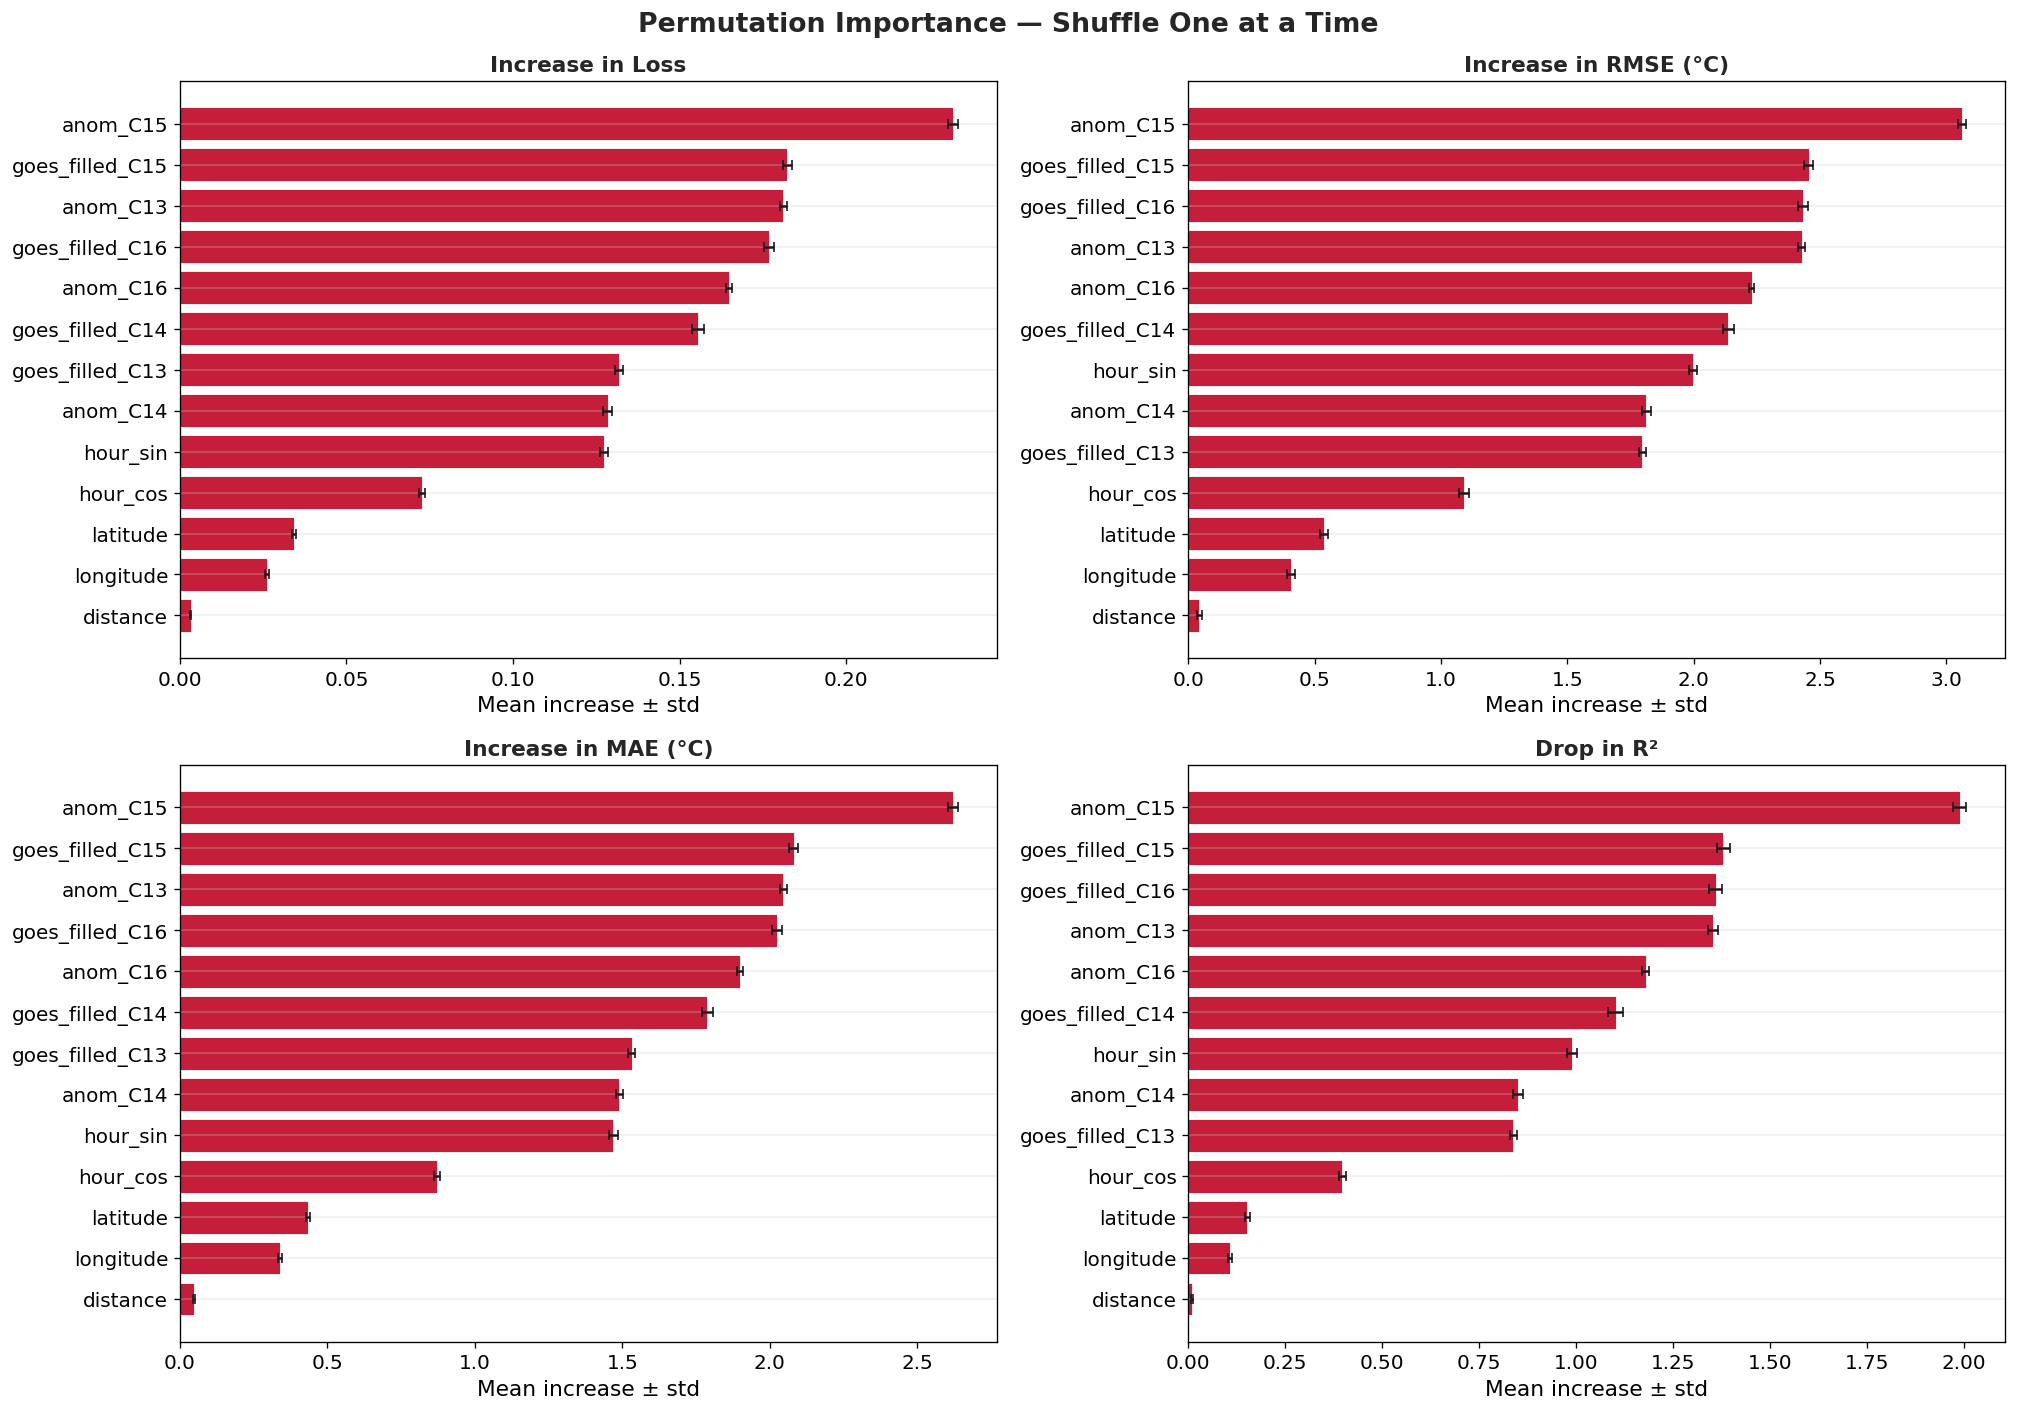


SUMMARY TABLE — PERMUTATION IMPORTANCE (ALL METRICS)
(each value = mean over 20 different random draws)
       variable  loss_delta_mean  loss_delta_std  rmse_delta_mean  rmse_delta_std  mae_delta_mean  mae_delta_std  r2_drop_mean  r2_drop_std
       anom_C15         0.232068        0.001494         3.062745        0.015777        2.621842       0.016783      1.989537     0.017239
goes_filled_C15         0.182238        0.001350         2.455097        0.018314        2.080945       0.015306      1.379496     0.016775
goes_filled_C16         0.176921        0.001548         2.433850        0.019645        2.024046       0.016969      1.360101     0.017852
       anom_C13         0.181115        0.001081         2.427301        0.014457        2.045520       0.012141      1.354122     0.013138
       anom_C16         0.164849        0.000872         2.228756        0.010226        1.900125       0.009673      1.179473     0.008713
goes_filled_C14         0.155546        0.001795       

In [22]:
# @title XAI 2 — permutation importance (shuffle one at a time)

N_REPEATS = best_cfg.n_repeats_pfi
pfi_results = []
t0 = time.time()

for group_name in ALL_GROUPS:
    runs = {'loss': [], 'rmse': [], 'mae': [], 'r2': []}
    for seed in range(N_REPEATS):
        backup = shuffle_groups_(test_batches, [group_name], seed=seed)
        m = eval_on_batches(model, test_batches)
        restore_(test_batches, backup)
        for k in runs:
            runs[k].append(m[k])

    row = {'variable': group_name}
    for k in ['loss', 'rmse', 'mae']:
        deltas = np.array(runs[k]) - baseline[k]      # increase = important
        row[f'{k}_delta_mean'] = deltas.mean()
        row[f'{k}_delta_std']  = deltas.std()
    r2_deltas = baseline['r2'] - np.array(runs['r2'])  # drop = important
    row['r2_drop_mean'] = r2_deltas.mean()
    row['r2_drop_std']  = r2_deltas.std()

    pfi_results.append(row)
    logger.info(
        f'  {group_name:18s} | Loss{row["loss_delta_mean"]:+.4f} '
        f'RMSE{row["rmse_delta_mean"]:+.4f} '
        f'MAE{row["mae_delta_mean"]:+.4f} '
        f'R² drop {row["r2_drop_mean"]:+.4f}'
    )

df_pfi = pd.DataFrame(pfi_results)
logger.info(f'Shuffle-one PFI done in {(time.time() - t0) / 60:.1f} min '
            f'({len(ALL_GROUPS)} variables x {N_REPEATS} repeats).')

# ── 4 panels: one per metric — variable colours match all other XAI plots ─────
fig, axes = plt.subplots(2, 2, figsize=(17, 12))
axes = axes.ravel()

panel_cfg = [
    ('loss_delta_mean', 'loss_delta_std', 'Increase in Loss'),
    ('rmse_delta_mean', 'rmse_delta_std', 'Increase in RMSE (°C)'),
    ('mae_delta_mean',  'mae_delta_std',  'Increase in MAE (°C)'),
    ('r2_drop_mean',    'r2_drop_std',    'Drop in R²'),
]
for ax, (mean_col, std_col, title) in zip(axes, panel_cfg):
    df_sorted = df_pfi.sort_values(mean_col, ascending=True)
    xai_barh(ax, df_sorted['variable'].tolist(), df_sorted[mean_col].values,
             errors=df_sorted[std_col].values,
             xlabel='Mean increase ± std',
             title=title)

fig.suptitle('Permutation Importance — Shuffle One at a Time', fontsize=16, fontweight='bold')
fig.tight_layout()
save_fig(fig, 'xai2_pfi_shuffle_one')

print('\n' + '=' * 90)
print('SUMMARY TABLE — PERMUTATION IMPORTANCE (ALL METRICS)')
print(f'(each value = mean over {N_REPEATS} different random draws)')
print('=' * 90)
print(df_pfi.sort_values('rmse_delta_mean', ascending=False).to_string(index=False))

### 11.3 · Permutation importance — leave one out

Inverse experiment: shuffle **everything except** one variable. Metrics close to the
baseline mean that variable alone carries most of the predictive signal.

19:04:18 | INFO     | Computing leave-one-out permutation importance...
19:04:21 | INFO     |   Kept: goes_filled_C13    | Loss=0.2288 RMSE=3.4535 MAE=2.7794 R²=-0.7217
19:04:24 | INFO     |   Kept: goes_filled_C14    | Loss=0.2380 RMSE=3.5782 MAE=2.8765 R²=-0.8482
19:04:26 | INFO     |   Kept: goes_filled_C15    | Loss=0.2248 RMSE=3.4250 MAE=2.7329 R²=-0.6934
19:04:29 | INFO     |   Kept: goes_filled_C16    | Loss=0.2263 RMSE=3.4355 MAE=2.7650 R²=-0.7037
19:04:32 | INFO     |   Kept: anom_C13           | Loss=0.2312 RMSE=3.4474 MAE=2.8112 R²=-0.7155
19:04:35 | INFO     |   Kept: anom_C14           | Loss=0.2143 RMSE=3.2845 MAE=2.6251 R²=-0.5573
19:04:37 | INFO     |   Kept: anom_C15           | Loss=0.2656 RMSE=3.9454 MAE=3.1711 R²=-1.2469
19:04:40 | INFO     |   Kept: anom_C16           | Loss=0.2196 RMSE=3.3673 MAE=2.6875 R²=-0.6368
19:04:43 | INFO     |   Kept: hour_sin           | Loss=0.2212 RMSE=3.3712 MAE=2.6979 R²=-0.6406
19:04:45 | INFO     |   Kept: hour_cos           | Loss

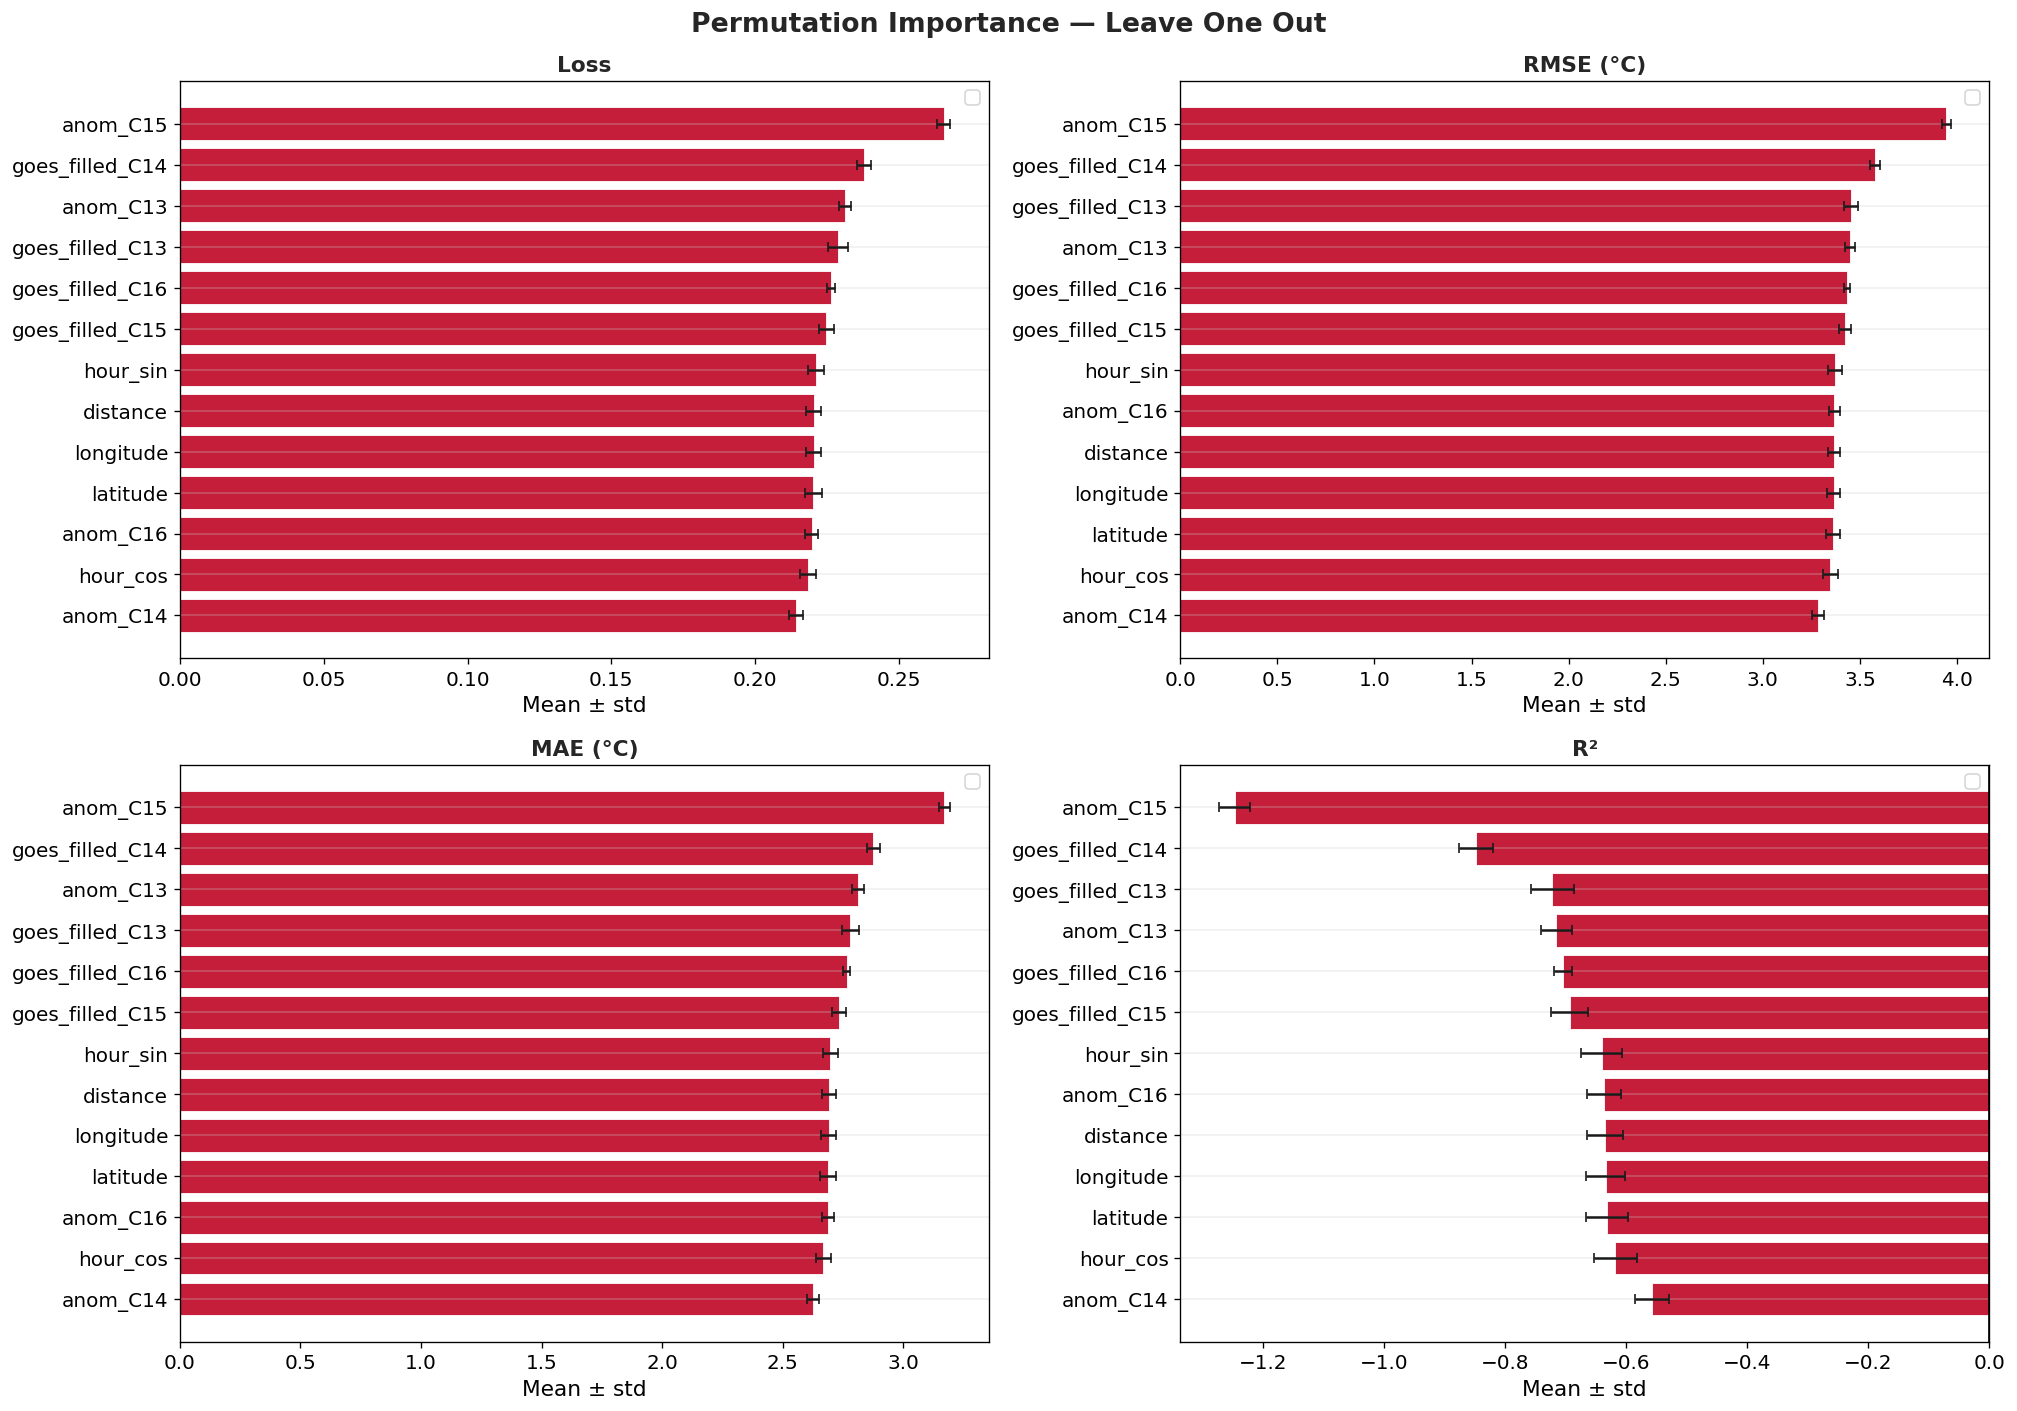


SUMMARY TABLE — LEAVE ONE OUT (ALL METRICS)
(mean over 20 runs | lower = more important, except R² where higher = more important)
       variable  loss_mean  loss_std  rmse_mean  rmse_std  mae_mean  mae_std   r2_mean   r2_std
       anom_C14   0.214300  0.002430   3.284498  0.030371  2.625113 0.026027 -0.557299 0.028795
       hour_cos   0.218464  0.002809   3.348081  0.036918  2.669008 0.032261 -0.618235 0.035458
       latitude   0.220247  0.002864   3.361827  0.036450  2.688968 0.032536 -0.631544 0.035176
      longitude   0.220338  0.002712   3.364206  0.033399  2.690188 0.030830 -0.633823 0.032256
       distance   0.220378  0.002653   3.365866  0.030722  2.690958 0.029309 -0.635410 0.029740
       anom_C16   0.219647  0.002269   3.367330  0.028428  2.687465 0.025137 -0.636814 0.027605
       hour_sin   0.221247  0.002842   3.371173  0.035226  2.697903 0.031611 -0.640614 0.034179
goes_filled_C15   0.224795  0.002527   3.425018  0.030595  2.732853 0.027759 -0.693391 0.030290
goes_

In [23]:
# @title XAI 3 — permutation importance (leave one out)

N_REPEATS_LOO = best_cfg.n_repeats_loo
loo_results = []
t0 = time.time()
logger.info('Computing leave-one-out permutation importance...')

for group_name in ALL_GROUPS:
    groups_to_shuffle = [g for g in ALL_GROUPS if g != group_name]
    runs = {'loss': [], 'rmse': [], 'mae': [], 'r2': []}
    for seed in range(N_REPEATS_LOO):
        backup = shuffle_groups_(test_batches, groups_to_shuffle, seed=seed)
        m = eval_on_batches(model, test_batches)
        restore_(test_batches, backup)
        for k in runs:
            runs[k].append(m[k])

    row = {'variable': group_name}
    for k in ['loss', 'rmse', 'mae', 'r2']:
        row[f'{k}_mean'] = np.mean(runs[k])
        row[f'{k}_std']  = np.std(runs[k])
    loo_results.append(row)
    logger.info(
        f'  Kept: {group_name:18s} | Loss={row["loss_mean"]:.4f} '
        f'RMSE={row["rmse_mean"]:.4f} MAE={row["mae_mean"]:.4f} '
        f'R²={row["r2_mean"]:.4f}'
    )

df_loo = pd.DataFrame(loo_results)
logger.info(f'Leave-one-out done in {(time.time() - t0) / 60:.1f} min.')

# ── 4 panels — same colour per variable as every other XAI plot ───────────────
fig, axes = plt.subplots(2, 2, figsize=(17, 12))
axes = axes.ravel()

panel_cfg_loo = [
    ('loss_mean', 'loss_std', 'Loss',      True),
    ('rmse_mean', 'rmse_std', 'RMSE (°C)', True),
    ('mae_mean',  'mae_std',  'MAE (°C)',  True),
    ('r2_mean',   'r2_std',   'R²',        False),
]
for ax, (mean_col, std_col, title, ascending) in zip(axes, panel_cfg_loo):
    df_sorted = df_loo.sort_values(mean_col, ascending=ascending)
    xai_barh(ax, df_sorted['variable'].tolist(), df_sorted[mean_col].values,
             errors=df_sorted[std_col].values,
             xlabel='Mean ± std',
             title=title)
    #if mean_col != 'r2_mean':
    #    ax.axvline(baseline[mean_col.replace('_mean', '')],
    #               color='black', ls='--', lw=1.5,
    #               label=f'Baseline = {baseline[mean_col.replace("_mean", "")]:.3f}')
    #else:
    #    ax.axvline(baseline['r2'], color='black', ls='--', lw=1.5,
    #               label=f'Baseline = {baseline["r2"]:.3f}')
    ax.legend(fontsize=11)

fig.suptitle('Permutation Importance — Leave One Out', fontsize=16, fontweight='bold')
fig.tight_layout()
save_fig(fig, 'xai3_pfi_leave_one_out')

print('\n' + '=' * 90)
print('SUMMARY TABLE — LEAVE ONE OUT (ALL METRICS)')
print(f'(mean over {N_REPEATS_LOO} runs | lower = more important, '
      f'except R² where higher = more important)')
print('=' * 90)
print(df_loo.sort_values('rmse_mean', ascending=True).to_string(index=False))

### 11.4 · SHAP surrogate — per-station attribution over 5 models

A gradient-boosting surrogate is fitted per station to mimic the GNN predictions of
the **5 stability models cached in §10** (no retraining). SHAP values are computed
exactly with `TreeExplainer` and grouped from 101 raw columns into the 13 variables.

*Fix vs the original notebook:* the latitude/longitude columns of the surrogate
feature matrix are now laid out to match their labels (previously the interleaved
`lat, lon` pixel values were mislabelled as 9 latitude then 9 longitude columns).

In [24]:
# @title XAI 4 — SHAP setup (feature matrices from the cached models)

import shap
from sklearn.ensemble import GradientBoostingRegressor

N_SHAP_SAMPLES = best_cfg.n_shap_samples
GOES_VARS = ['goes_filled_C13', 'goes_filled_C14', 'goes_filled_C15', 'goes_filled_C16',
             'anom_C13', 'anom_C14', 'anom_C15', 'anom_C16']
K = best_cfg.knn_k
N_COLS = 8 * K + 2 + 2 * K + K   # 8 GOES vars x k px + hour_sin/cos + lat/lon x k + dist x k

# ── Column names & display groups (101 columns -> 13 variables for k=9) ───────
col_names_full = []
for var in GOES_VARS:
    col_names_full += [f'{var}_px{i}' for i in range(K)]
col_names_full += ['hour_sin', 'hour_cos']
col_names_full += [f'latitude_px{i}' for i in range(K)]
col_names_full += [f'longitude_px{i}' for i in range(K)]
col_names_full += [f'distance_px{i}' for i in range(K)]
assert len(col_names_full) == N_COLS

DISPLAY_GROUPS, idx = {}, 0
for var in GOES_VARS:
    DISPLAY_GROUPS[var] = list(range(idx, idx + K)); idx += K
DISPLAY_GROUPS['hour_sin'] = [idx]; idx += 1
DISPLAY_GROUPS['hour_cos'] = [idx]; idx += 1
DISPLAY_GROUPS['latitude']  = list(range(idx, idx + K)); idx += K
DISPLAY_GROUPS['longitude'] = list(range(idx, idx + K)); idx += K
DISPLAY_GROUPS['distance']  = list(range(idx, idx + K)); idx += K
group_names = list(DISPLAY_GROUPS.keys())


def build_station_matrix(goes_stack: np.ndarray, edge_attr: np.ndarray,
                         edge_index: np.ndarray, station_idx: int) -> np.ndarray:
    """Vectorised (T, N_COLS) feature matrix with the k real values per variable."""
    mask = edge_index[1] == station_idx
    nb   = edge_index[0][mask]                        # (k,)
    view = goes_stack[:, nb, :]                       # (T, k, 12)
    T = view.shape[0]
    goes_flat = view[:, :, :8].transpose(0, 2, 1).reshape(T, 8 * K)   # var-major, matches names
    hour      = view[:, 0, 8:10]                                       # (T, 2)
    lat_flat  = view[:, :, 10]                                         # (T, k)
    lon_flat  = view[:, :, 11]                                         # (T, k)
    dist_k    = np.broadcast_to(edge_attr[mask, 0], (T, K))            # (T, k) constant
    return np.concatenate([goes_flat, hour, lat_flat, lon_flat, dist_k], axis=1)


# ── Collect feature matrices + predictions from the 5 cached models ───────────
logger.info('=' * 70)
logger.info(f'SHAP — {len(best_cfg.stability_seeds)} cached models x '
            f'{N_SHAP_SAMPLES} timesteps each (no retraining)')
logger.info('=' * 70)

all_feat_per_station  = {s: [] for s in station_names}
all_preds_per_station = {s: [] for s in station_names}

for seed in best_cfg.stability_seeds:
    art = split_artifacts[seed]
    test_graphs_s, graph_prep_s, preds_s = art['test_graphs'], art['graph_prep'], art['preds']

    goes_stack_s = torch.stack([g['goes'].x for g in test_graphs_s]).cpu().numpy()
    edge_index_s = graph_prep_s.edge_index_goes_sta_.numpy()
    edge_attr_s  = graph_prep_s.edge_attr_goes_sta_.numpy()

    T_test     = len(test_graphs_s)
    n_sample   = min(N_SHAP_SAMPLES, T_test)
    rng        = np.random.RandomState(seed)
    sample_idx = rng.choice(T_test, size=n_sample, replace=False)

    for s_idx, s_name in enumerate(station_names):
        feat_full = build_station_matrix(goes_stack_s, edge_attr_s, edge_index_s, s_idx)
        all_feat_per_station[s_name].append(feat_full[sample_idx])
        all_preds_per_station[s_name].append(preds_s[sample_idx, s_idx].numpy())

    logger.info(f'  seed {seed}: {n_sample} timesteps collected per station')

19:04:55 | INFO     | ======================================================================
19:04:55 | INFO     | SHAP — 5 cached models x 1000 timesteps each (no retraining)
19:04:55 | INFO     | ======================================================================
19:04:55 | INFO     |   seed 42: 1000 timesteps collected per station
19:04:55 | INFO     |   seed 7: 1000 timesteps collected per station
19:04:55 | INFO     |   seed 123: 1000 timesteps collected per station
19:04:55 | INFO     |   seed 999: 1000 timesteps collected per station
19:04:55 | INFO     |   seed 2024: 1000 timesteps collected per station


19:04:55 | INFO     | Fitting surrogates and computing SHAP per station...
19:04:55 | INFO     | --- SHAP station BSEC-AAC_AWS ---
19:04:55 | INFO     |   5000 observations x 101 features
19:05:16 | INFO     |   Surrogate <-> GNN fidelity: R²=0.5426 (WARNING low)
19:05:18 | INFO     | Figure saved -> GNN_Baltimore/figures/xai4_shap_summary_BSEC-AAC_AWS.pdf


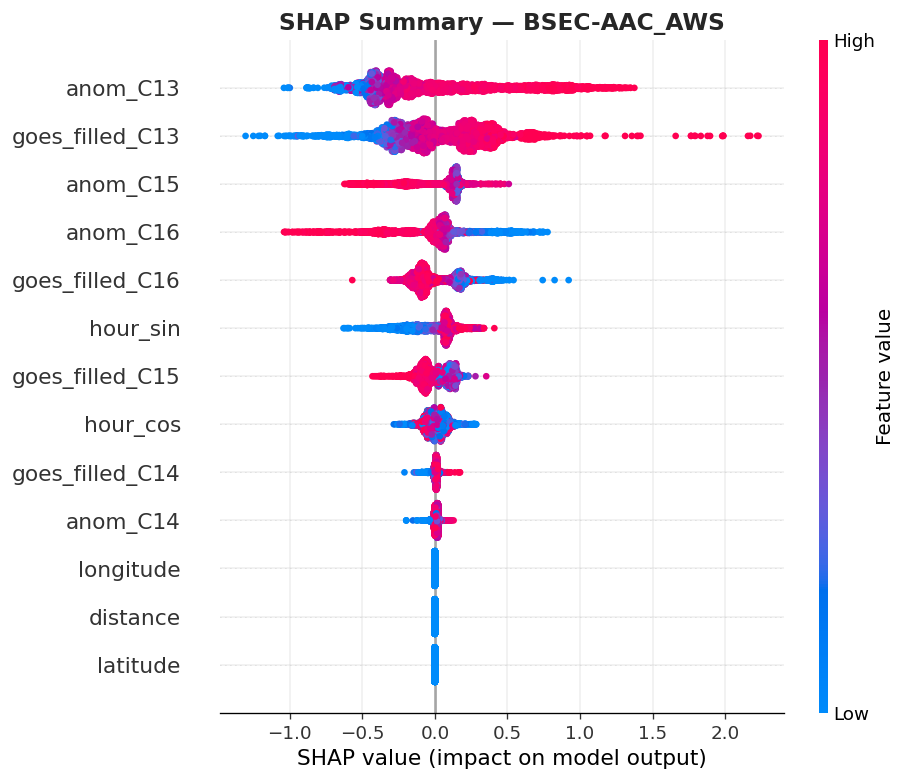

19:05:19 | INFO     | Figure saved -> GNN_Baltimore/figures/xai4_shap_importance_BSEC-AAC_AWS.pdf


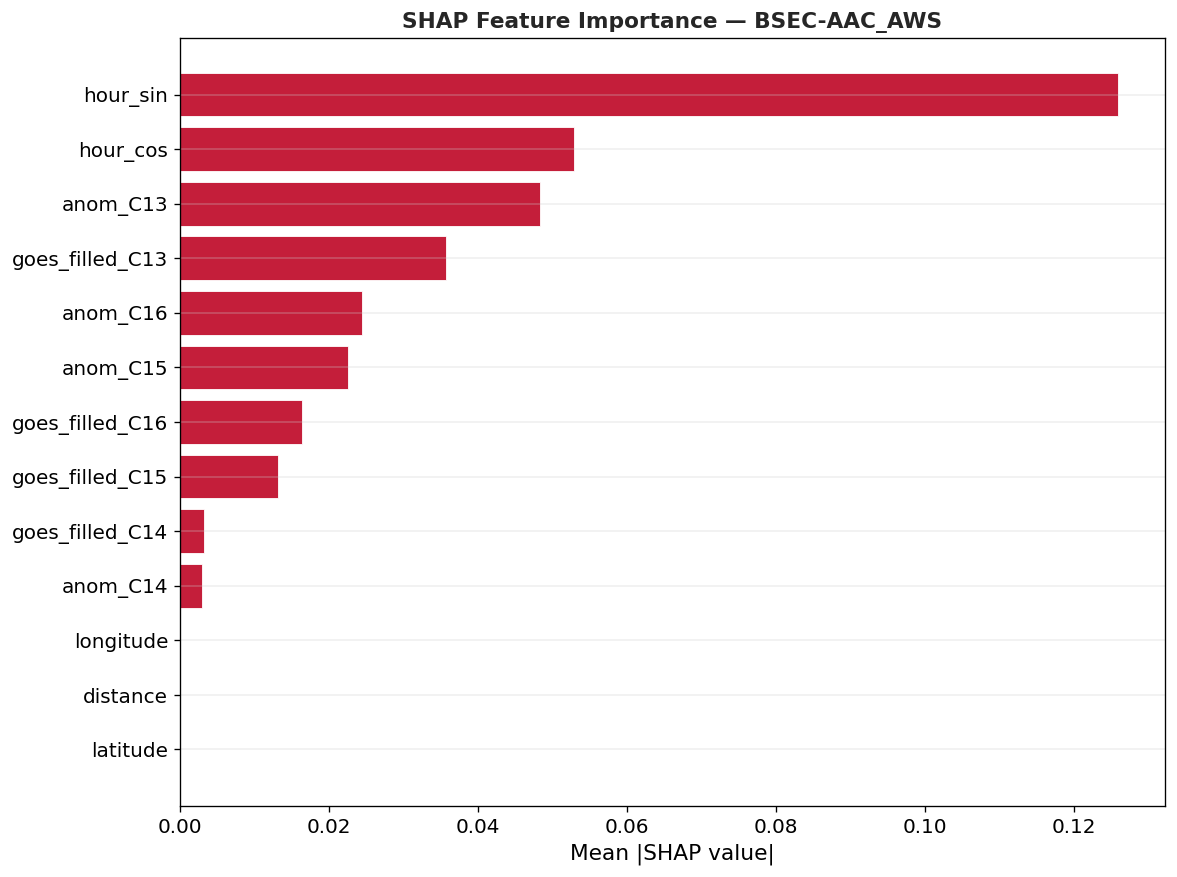

19:05:19 | INFO     |   Top 3: hour_sin=0.1260  |  hour_cos=0.0529  |  anom_C13=0.0484
19:05:19 | INFO     | --- SHAP station BSEC-COV_AWS ---
19:05:19 | INFO     |   5000 observations x 101 features
19:05:38 | INFO     |   Surrogate <-> GNN fidelity: R²=0.5531 (WARNING low)
19:05:40 | INFO     | Figure saved -> GNN_Baltimore/figures/xai4_shap_summary_BSEC-COV_AWS.pdf


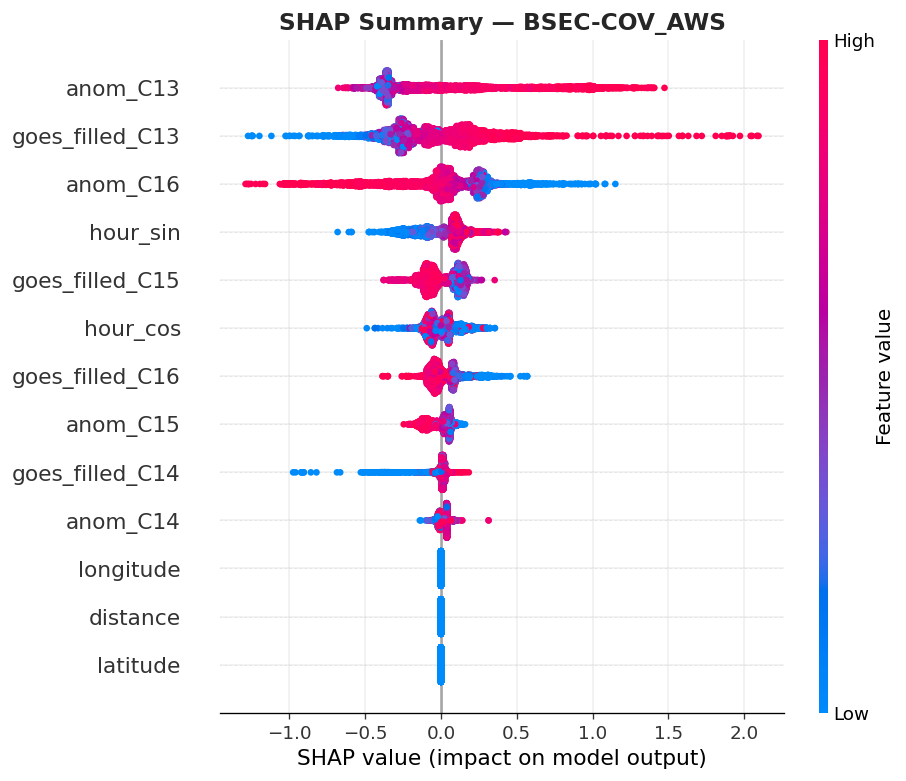

19:05:41 | INFO     | Figure saved -> GNN_Baltimore/figures/xai4_shap_importance_BSEC-COV_AWS.pdf


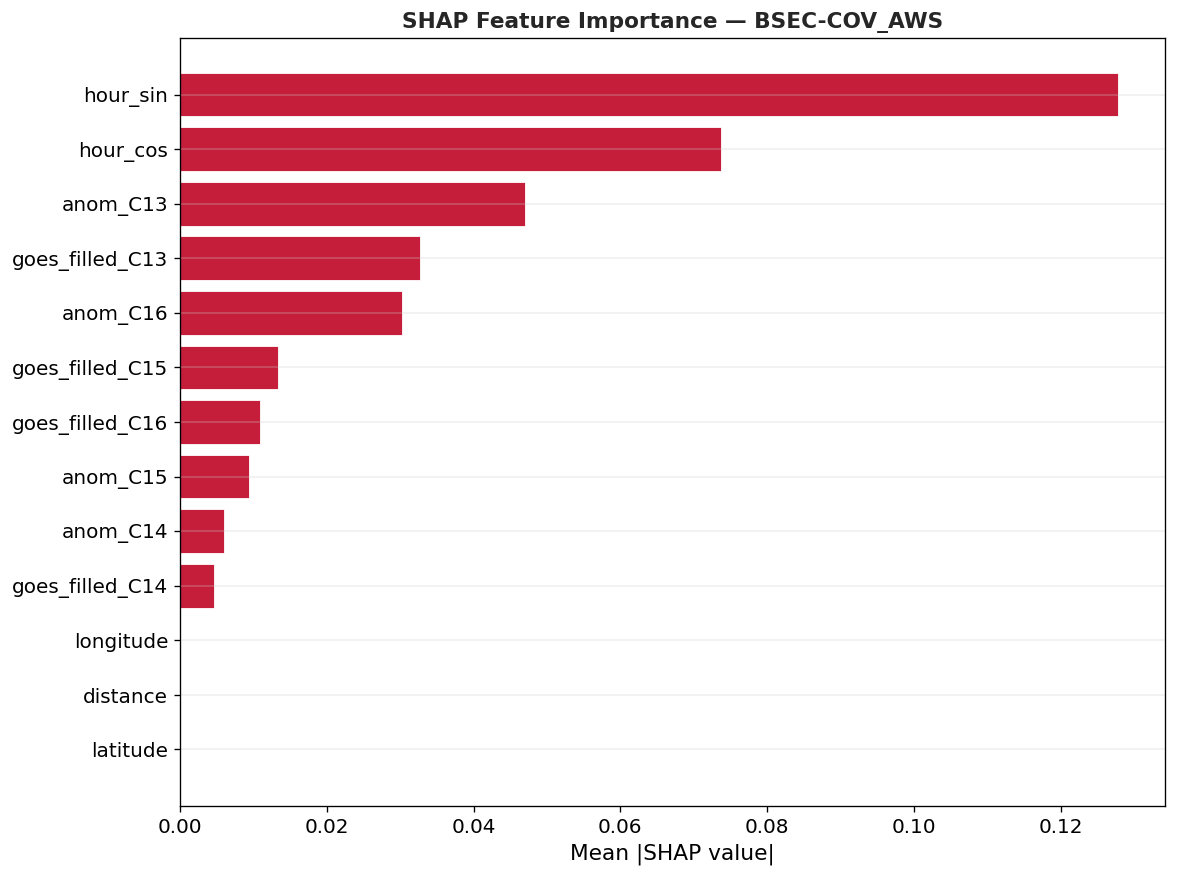

19:05:41 | INFO     |   Top 3: hour_sin=0.1278  |  hour_cos=0.0737  |  anom_C13=0.0470
19:05:41 | INFO     | --- SHAP station BSEC-JHU_AWS ---
19:05:41 | INFO     |   5000 observations x 101 features
19:06:00 | INFO     |   Surrogate <-> GNN fidelity: R²=0.5521 (WARNING low)
19:06:02 | INFO     | Figure saved -> GNN_Baltimore/figures/xai4_shap_summary_BSEC-JHU_AWS.pdf


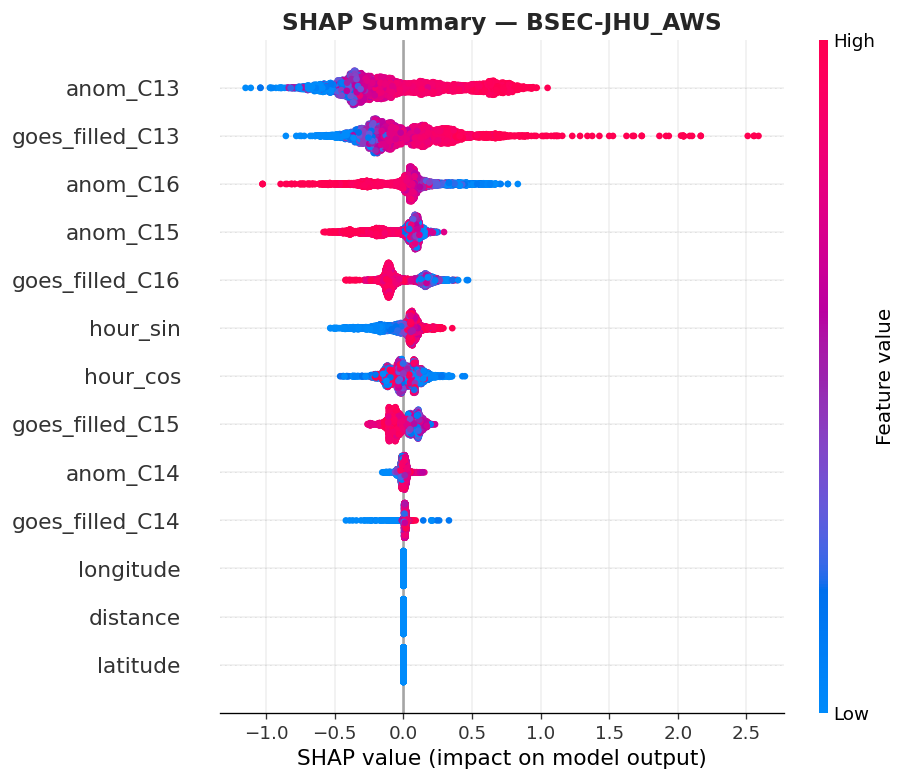

19:06:02 | INFO     | Figure saved -> GNN_Baltimore/figures/xai4_shap_importance_BSEC-JHU_AWS.pdf


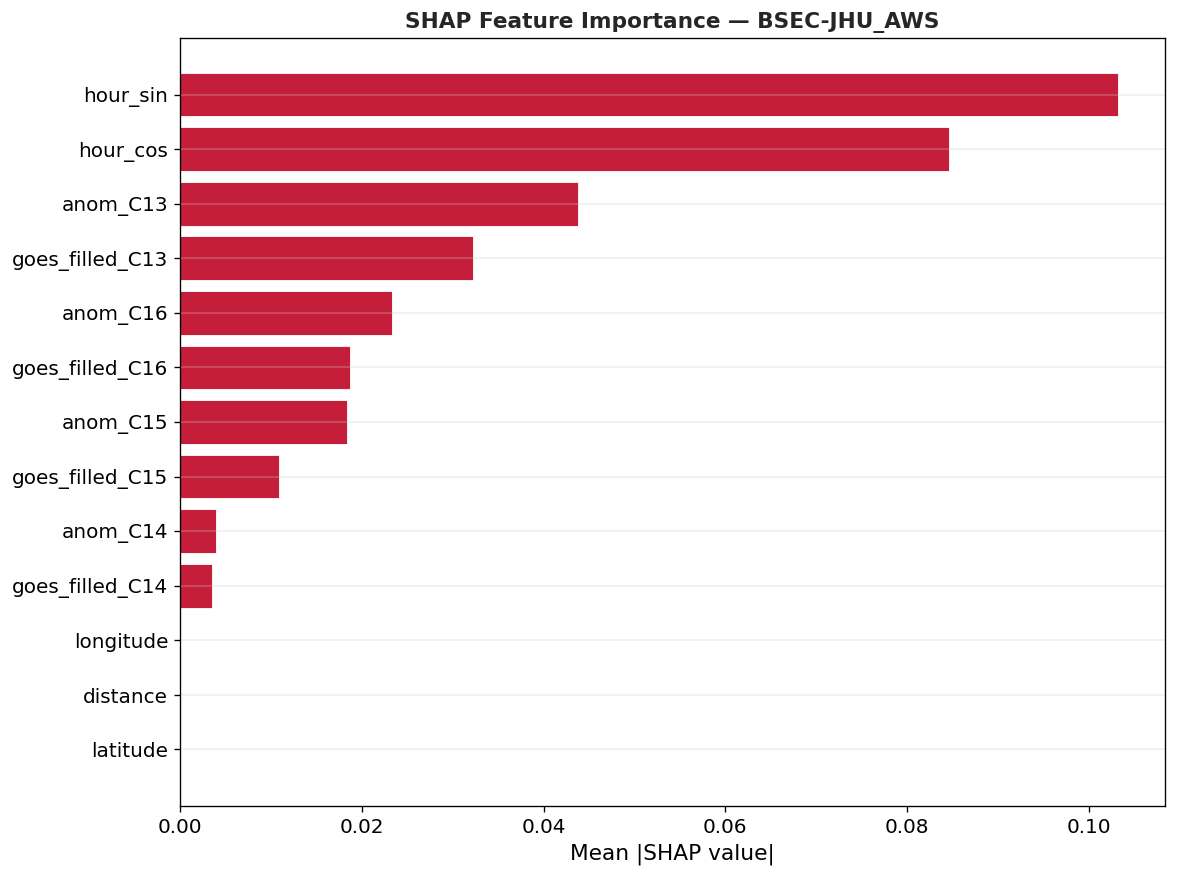

19:06:02 | INFO     |   Top 3: hour_sin=0.1032  |  hour_cos=0.0846  |  anom_C13=0.0438
19:06:02 | INFO     | ======================================================================
19:06:02 | INFO     | SHAP completed — surrogates mimic the 5 cached stability models; attributions are more robust than with a single model.


In [25]:
# @title XAI 4 — SHAP per station (surrogate + TreeExplainer + plots)

logger.info('Fitting surrogates and computing SHAP per station...')
shap_results_per_station = {}

for s_idx, s_name in enumerate(station_names):
    logger.info(f'--- SHAP station {s_name} ---')

    # Concatenate the 5 seeds -> (5 x N_SHAP_SAMPLES, N_COLS)
    feat_matrix = np.concatenate(all_feat_per_station[s_name],  axis=0)
    gnn_preds   = np.concatenate(all_preds_per_station[s_name], axis=0)
    logger.info(f'  {feat_matrix.shape[0]} observations x {feat_matrix.shape[1]} features')

    # Surrogate trained to mimic the 5 GNNs
    surrogate = GradientBoostingRegressor(
        n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42
    )
    surrogate.fit(feat_matrix, gnn_preds)

    fidelity_r2 = r2_score(gnn_preds, surrogate.predict(feat_matrix))
    logger.info(f'  Surrogate <-> GNN fidelity: R²={fidelity_r2:.4f} '
                f'({"OK" if fidelity_r2 > 0.85 else "WARNING low"})')

    # Exact SHAP via TreeExplainer
    explainer = shap.TreeExplainer(surrogate)
    shap_vals = explainer.shap_values(feat_matrix)          # (N_total, N_COLS)

    # Group raw columns -> 13 variables
    group_mean_shap, group_shap_ts, group_feat_vals = [], [], []
    for gname, gcols in DISPLAY_GROUPS.items():
        group_mean_shap.append(np.abs(shap_vals[:, gcols]).mean())
        group_shap_ts.append(shap_vals[:, gcols].sum(axis=1))
        group_feat_vals.append(feat_matrix[:, gcols].mean(axis=1))
    group_mean_shap = np.array(group_mean_shap)
    group_shap_ts   = np.array(group_shap_ts).T
    group_feat_vals = np.array(group_feat_vals).T

    shap_results_per_station[s_name] = {
        'shap_grouped'   : group_shap_ts,
        'group_mean_shap': group_mean_shap,
        'fidelity_r2'    : fidelity_r2,
        'n_obs'          : feat_matrix.shape[0],
    }

    # ── Plot 1: SHAP summary (beeswarm) ───────────────────────────────────────
    fig = plt.figure(figsize=(10, 7.5))
    shap.summary_plot(group_shap_ts, group_feat_vals,
                      feature_names=group_names, show=False)
    plt.gca().set_title(f'SHAP Summary — {s_name}', fontsize=14, fontweight='bold')
    fig = plt.gcf()
    fig.tight_layout()
    save_fig(fig, f'xai4_shap_summary_{s_name}')

    # ── Plot 2: mean |SHAP| bars — same variable colours as PFI plots ─────────
    order = np.argsort(group_mean_shap)
    fig, ax = plt.subplots(figsize=(10, 7.5))
    xai_barh(ax,
             [group_names[i] for i in order],
             group_mean_shap[order],
             xlabel='Mean |SHAP value|',
             title=f'SHAP Feature Importance — {s_name}')
    fig.tight_layout()
    save_fig(fig, f'xai4_shap_importance_{s_name}')

    logger.info('  Top 3: ' + '  |  '.join(
        f'{group_names[i]}={group_mean_shap[i]:.4f}'
        for i in np.argsort(group_mean_shap)[::-1][:3]))

logger.info('=' * 70)
logger.info('SHAP completed — surrogates mimic the 5 cached stability models; '
            'attributions are more robust than with a single model.')

## 12 · Outputs

In [26]:
# @title List saved figures
for p in sorted(cfg.fig_dir.glob('*.pdf')):
    print(f'{p.stat().st_size / 1024:8.1f} KB   {p.name}')

    39.2 KB   features_dynamic_hist.pdf
    20.8 KB   features_static_hist.pdf
    18.1 KB   features_targets_hist.pdf
   102.8 KB   final_predictions_test.pdf
   103.1 KB   final_predictions_val.pdf
    26.7 KB   final_training_history.pdf
    26.1 KB   graph_topology.pdf
    23.8 KB   hpo_stageA_architecture.pdf
    19.4 KB   hpo_stageB_loss.pdf
    70.5 KB   split_dist_features.pdf
    32.2 KB   split_dist_targets.pdf
    20.2 KB   stability_splits.pdf
    27.6 KB   xai1_corr_BSEC-AAC_AWS.pdf
    28.0 KB   xai1_corr_BSEC-COV_AWS.pdf
    28.2 KB   xai1_corr_BSEC-JHU_AWS.pdf
    30.0 KB   xai2_pfi_shuffle_one.pdf
    30.0 KB   xai3_pfi_leave_one_out.pdf
    22.5 KB   xai4_shap_importance_BSEC-AAC_AWS.pdf
    23.0 KB   xai4_shap_importance_BSEC-COV_AWS.pdf
    22.9 KB   xai4_shap_importance_BSEC-JHU_AWS.pdf
    73.3 KB   xai4_shap_summary_BSEC-AAC_AWS.pdf
    74.1 KB   xai4_shap_summary_BSEC-COV_AWS.pdf
    72.6 KB   xai4_shap_summary_BSEC-JHU_AWS.pdf
